# 📊 Exploratory Data Analysis (EDA) Plan

*Statistical Characterization of the PTB-XL Dataset*

---

## 🎯 Objectives of EDA

The purpose of EDA is to:

1. Understand population characteristics
2. Quantify label distribution and imbalance
3. Assess signal properties
4. Identify potential sources of bias
5. Inform modeling and validation strategy

EDA is not visualization for aesthetics — it is **pre-model statistical reconnaissance**.

---

# 1️⃣ Cohort Characterization

## 1.1 Sample Size

* Total number of ECG recordings
* Total number of unique patients
* Recordings per patient distribution

**Why it matters:**
Prevents patient-level data leakage and informs split strategy.

---

## 1.2 Demographics

### Age

* Mean ± SD
* Median (IQR)
* Histogram
* Age bins (e.g., <40, 40–60, >60)

### Sex

* Counts and percentages
* Bar plot

**Why it matters:**
Enables subgroup analysis and bias assessment.

---

# 2️⃣ Label Distribution Analysis

PTB-XL is multi-label.

## 2.1 Diagnostic Superclasses

Compute:

* Count per class
* Prevalence (%)
* Co-occurrence matrix

Display:

* Bar plot of class frequencies
* Heatmap of label co-occurrence

**Why it matters:**

* Detects severe imbalance
* Guides weighted loss design
* Informs macro vs micro metric choice

---

## 2.2 Label Cardinality

* Average number of labels per ECG
* Distribution of label counts

This tells you:

* How multi-label the dataset actually is

---

# 3️⃣ Signal-Level Analysis

(Using 500 Hz or 100 Hz data)

## 3.1 Signal Length

* Confirm uniform length
* Check for missing or corrupted files

## 3.2 Amplitude Distribution

* Mean amplitude per lead
* Standard deviation per lead
* Outlier detection

## 3.3 Lead Correlation

* Correlation matrix between leads
* Detect redundancy or abnormal signals

---

# 4️⃣ Missingness Analysis

* Missing demographic data
* Missing labels
* Missing signals

If present:

* Quantify proportion
* Determine missingness pattern (MCAR/MAR suspicion)

---

# 5️⃣ Train/Test Split Validation

Before training:

* Confirm patient-level split
* Compare:

  * Age distribution (train vs test)
  * Sex distribution
  * Label prevalence

Use:

* t-test or Mann–Whitney (age)
* Chi-square test (sex, labels)

**Goal:** Ensure no distributional shift between splits.

---

# 6️⃣ Class Imbalance Quantification

Compute:

* Imbalance ratio (max/min class frequency)
* Effective number of samples (for weighted loss)

Decide:

* Class weights
* Focal loss?
* Threshold tuning strategy?

---

# 7️⃣ Correlation Between Demographics and Labels

Example analyses:

* Age vs MI prevalence
* Sex vs conduction disorders

Use:

* Logistic regression (univariate)
* Odds ratios with 95% CI

This gives you publishable-level descriptive stats.

---

# 📈 Key Tables to Produce

| Table   | Description                           |
| ------- | ------------------------------------- |
| Table 1 | Baseline Demographics                 |
| Table 2 | Diagnostic Class Prevalence           |
| Table 3 | Label Co-occurrence Matrix            |
| Table 4 | Train vs Test Distribution Comparison |

---

# 🧠 Statistical Framing

EDA is answering:

* Is the dataset representative?
* Is it balanced?
* Is it suitable for macro-AUC evaluation?
* Are there confounders?
* Will subgroup analysis be powered?

---

# 🚨 Red Flags to Look For

* Extreme class imbalance (<1%)
* One sex dominating a diagnostic label
* Age skew in test set
* Highly correlated labels
* Duplicate patients across splits

In [3]:
# --------------------------------------------------
# Importing necessary libraries
# --------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import ast
import wfdb

## 1️⃣ Load the Data

In [4]:
# --------------------------------------------------
# Setting up paths
# --------------------------------------------------
ROOT      = Path.cwd().parent                          # ecg-ai-statistical-evaluation/
DATA      = ROOT / 'data'                              # ecg-ai-statistical-evaluation/data/

PTBXL_DB  = DATA / 'ptbxl_database.csv'               # patient demographics
SCP       = DATA / 'scp_statements.csv'                # SCP codes
ECG_100HZ = DATA / 'records100'                        # 100 Hz ECG signals
ECG_500HZ = DATA / 'records500'                        # 500 Hz ECG signals (for final model)

# --------------------------------------------------
# Sanity checks — fails loudly if structure is wrong
# --------------------------------------------------
assert ROOT.exists(),      f"Project root not found: {ROOT}"
assert PTBXL_DB.exists(),  f"Metadata CSV not found: {PTBXL_DB}"
assert SCP.exists(),       f"SCP statements not found: {SCP}"
assert ECG_100HZ.exists(), f"records100 not found: {ECG_100HZ}"

print(f"All paths verified. Root: {ROOT.resolve()}")

All paths verified. Root: C:\Users\delga\OneDrive\Documents\personal_projects\DeepAF Automated Atrial Fibrillation Detection\ecg-ai-statistical-evaluation


In [5]:
# --------------------------------------------------
# Loading Patient Information
# --------------------------------------------------
df = pd.read_csv(PTBXL_DB, sep=",", index_col='ecg_id')

# print basic info about the dataframe
print(df.info())
print(df.describe())
print(df.shape)


<class 'pandas.core.frame.DataFrame'>
Index: 21799 entries, 1 to 21837
Data columns (total 27 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   patient_id                    21799 non-null  float64
 1   age                           21799 non-null  float64
 2   sex                           21799 non-null  int64  
 3   height                        6974 non-null   float64
 4   weight                        9421 non-null   float64
 5   nurse                         20326 non-null  float64
 6   site                          21782 non-null  float64
 7   device                        21799 non-null  object 
 8   recording_date                21799 non-null  object 
 9   report                        21799 non-null  object 
 10  scp_codes                     21799 non-null  object 
 11  heart_axis                    13331 non-null  object 
 12  infarction_stadium1           5612 non-null   object 
 13  infarc

In [6]:
df.head()

,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
ecg_id,,,,,,,,,,,,,,,,,,,,,
1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,sinusrhythmus periphere niederspannung,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,sinusbradykardie sonst normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,sinusrhythmus normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,sinusrhythmus normales ekg,...,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,sinusrhythmus normales ekg,...,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


# 2️⃣ Diagnostic Labels

The diagnostic Labels are in a format where more than 1 condition can be present based on the ECG and cardiologist interpretation. These classifications are the scp codes. The possible scp codes are `['NORM','MI','STTC','CD','HYP']`. These are the five major dignostic superclasses used to classify ECG signals. 
* NORM: Normal ECG
* MI (Myocardial Infarction): Indicates heart attacks. 
* STTC (ST/T Change): Indicates abnormalitioes in the ST segment or the T wave. 
* CD (Conduction Disturbance): Disturbances in the heart's electrical conduction system.
* HYP (Hypertrophy): Enlargement of the heart muscle. 

Source: [PubMed, Deep Learning Models for Arrhythmia Classification Based on ECG Signals Using PTB-X Dataset](https://pmc.ncbi.nlm.nih.gov/articles/PMC12346745/)

Need to encode these classifications which act as our ground truth through Multilabel Encoder.

In [7]:
# -- 2. Load SCP statements & filter to diagnostic only --
df['scp_codes'] = df['scp_codes'].apply(ast.literal_eval)

# Load SCP statements to get superclass mappings
agg_df = pd.read_csv('../data/scp_statements.csv', index_col=0)
agg_df = agg_df[agg_df.diagnostic == 1]

# -- 3. Map SCP Codes -> Diagnostic superclass
def get_superclass(scp_dict):
    classes = []
    # Loop through the scp_dict for an ECG interpretation
    for key in scp_dict.keys():
        # Add present SCP codes under a new column called diagnostic_class and store it into classes 
        if key in agg_df.index:
            classes.append(agg_df.loc[key, 'diagnostic_class'])
    return list(set(classes))

df['superclass'] = df['scp_codes'].apply(get_superclass)
df = df[df['superclass'].map(len) > 0]  # drop records with no diagnostic label

print(df['superclass'].value_counts())

superclass
[NORM]                 9069
[MI]                   2532
[STTC]                 2400
[CD]                   1708
[MI, CD]               1297
[HYP, STTC]             781
[MI, STTC]              599
[HYP]                   535
[CD, STTC]              471
[NORM, CD]              407
[MI, HYP, STTC]         361
[HYP, CD]               300
[MI, CD, STTC]          223
[HYP, CD, STTC]         211
[MI, HYP]               183
[MI, HYP, CD, STTC]     156
[MI, HYP, CD]           117
[NORM, STTC]             28
[NORM, CD, STTC]          5
[HYP, NORM, CD]           2
[HYP, NORM]               2
[HYP, MI, NORM, CD]       1
Name: count, dtype: int64


In [8]:
from sklearn.preprocessing import MultiLabelBinarizer
# -- 4. Apply Multilabel Binarizer --

# Encode the SCP codes where 1 indictaes condition is present and 0 indictes it is not
mlb = MultiLabelBinarizer(classes=['NORM','MI','STTC','CD','HYP'])
Y = mlb.fit_transform(df['superclass']) # The shape should be (N, 5)
print(Y.shape)

(21388, 5)


In [9]:
# ---------------------------------------------------
# Sanity Checks on the extracted superclasses
# ---------------------------------------------------

# Check how many ECGs have at least one diagnostic label
n_with_labels = (df["superclass"].apply(len) > 0).sum()
n_total = len(df)

print(f"ECGs with diagnostic labels: {n_with_labels}/{n_total}")
print(f"Percentage labeled: {100 * n_with_labels / n_total:.2f}%")

# Check for empty labels
empty_labels = df[df["superclass"].apply(len) == 0]
print("Number of ECGs with NO diagnostic superclass:", len(empty_labels))

ECGs with diagnostic labels: 21388/21388
Percentage labeled: 100.00%
Number of ECGs with NO diagnostic superclass: 0


In [10]:
# Count the occurrences of each superclass
all_classes = [cls for sublist in df["superclass"] for cls in sublist]
class_counts = pd.Series(all_classes).value_counts()

print("\nDiagnostic Superclass Counts:")
print(class_counts)


Diagnostic Superclass Counts:
NORM    9514
MI      5469
STTC    5235
CD      4898
HYP     2649
Name: count, dtype: int64


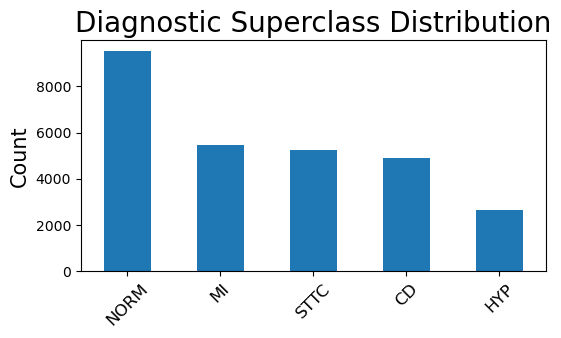

In [11]:
# -- Make a figure showing the Superclass Distributions --
plt.figure(figsize=(6, 3), facecolor='white')

# Define fontsizes
label = 15 
title = 20 
ticks = 12

# Plot class_counts
class_counts.plot(kind="bar")
plt.title("Diagnostic Superclass Distribution", fontsize=title)
plt.ylabel("Count", fontsize=label)
plt.xticks(rotation=45, fontsize=ticks)
plt.show()

### Define the splits 

In [12]:
# Define column split with default assigned as 'train'
df['split'] = 'train'

# folds 9 and 10 are meant to be validation and test folds 
df.loc[(df["strat_fold"] == 9), 'split'] = 'val' # assign validation to fold 9
df.loc[(df["strat_fold"] == 10), 'split'] = 'test' # assign test to fold 10

## Generate Table 1 Summary Statistics

In [13]:
CLASS_ORDER = ['NORM', 'MI', 'STTC', 'CD', 'HYP']  # module-level constant

def cohort_summary_stats(df: pd.DataFrame) -> pd.DataFrame:
    """
    Generate a Table 1 cohort summary for the PTB-XL dataset.

    Args:
        df (pd.DataFrame): Dataframe containing 'patient_id', 'age', 'sex',
                           and 'superclass' columns.

    Returns:
        pd.DataFrame: Summary table with columns ['Characteristic', 'Value'].
    """
    df = df.copy()  # never mutate the caller's dataframe

    # -- Cohort size --
    n_records  = df.shape[0]
    n_patients = df['patient_id'].nunique()

    # -- Age --
    # Correct HIPAA-compliant encoding: age > 89 stored as 300 in PTB-XL
    df.loc[df['age'] >= 89, 'age'] = 90

    age_mean   = df['age'].mean()
    age_sd     = df['age'].std(ddof=1)  # explicit: sample standard deviation
    age_median = df['age'].median()
    age_q1     = df['age'].quantile(0.25)
    age_q3     = df['age'].quantile(0.75)

    # -- Sex --
    # PTB-XL encodes 0 = Female, 1 = Male
    sex_counts  = (df['sex']
                   .value_counts()
                   .rename({0: 'Female', 1: 'Male'})
                   .reindex(['Female', 'Male'], fill_value=0))  # explicit order, safe if one sex missing
    sex_percent = sex_counts / n_records * 100

    # -- Diagnostic superclasses --
    # Multi-label: % = records containing this class / total records
    all_classes   = [cls for sublist in df['superclass'] for cls in sublist]
    class_counts  = (pd.Series(all_classes)
                     .value_counts()
                     .reindex(CLASS_ORDER, fill_value=0))  # consistent clinical order
    class_percent = class_counts / n_records * 100

    # -- Build table --
    rows = []

    rows.append(["Total ECG Recordings", f"{n_records:,}"])
    rows.append(["Unique Patients",       f"{n_patients:,}"])
    rows.append(["Age (years), mean ± SD",
                 f"{age_mean:.1f} ± {age_sd:.1f}"])
    rows.append(["Age (years), median (IQR)",
                 f"{age_median:.1f} ({age_q1:.1f}–{age_q3:.1f})"])

    for sex in sex_counts.index:
        rows.append([f"Sex: {sex}",
                     f"{sex_counts[sex]:,} ({sex_percent[sex]:.1f}%)"])

    for cls in class_counts.index:
        rows.append([f"Diagnosis: {cls}",
                     f"{class_counts[cls]:,} ({class_percent[cls]:.1f}%)"])

    return pd.DataFrame(rows, columns=["Characteristic", "Value"])
# -----------------------------------------------------------------------------------------------------------------------------------
def plot_cohort_summary_stats(df: pd.DataFrame) -> dict:
    """
    Visualize cohort-level summary statistics.
    Companion plotting function to cohort_summary_stats().

    Args:
        df (pd.DataFrame): Raw dataframe containing 'age', 'sex',
                           and 'superclass' columns.

    Returns:
        dict: Dictionary of matplotlib figures keyed by plot name.
    """
    cohort_plots = {}

    df = df.copy()
    df.loc[df['age'] >= 89, 'age'] = 90
    df['sex_label'] = df['sex'].map({0: 'Female', 1: 'Male'})

    n_records   = len(df)
    SEX_PALETTE = {'Female': '#D4537E', 'Male': '#378ADD'}

    # ── 1. Age histogram with KDE ─────────────────────────────────────────────
    fig1, ax1 = plt.subplots(figsize=(9, 4))
    sns.histplot(
        data=df, x='age', bins=30,
        color='#378ADD', alpha=0.6,
        kde=True, line_kws={'linewidth': 2},
        ax=ax1
    )
    ax1.axvline(df['age'].median(), color='#D4537E', linewidth=1.5,
                linestyle='--', label=f"Median: {df['age'].median():.0f} yrs")
    ax1.set_title('Age distribution — full cohort', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Age (years)')
    ax1.set_ylabel('Number of records')
    ax1.legend()
    sns.despine(ax=ax1)
    fig1.tight_layout()
    cohort_plots['age_histogram'] = fig1

    # ── 2. Sex distribution bar ───────────────────────────────────────────────
    sex_counts  = df['sex_label'].value_counts().reindex(['Female', 'Male'], fill_value=0)
    sex_percent = sex_counts / n_records * 100

    fig2, ax2 = plt.subplots(figsize=(5, 4))
    bars = ax2.bar(
        sex_counts.index, sex_counts.values,
        color=[SEX_PALETTE[s] for s in sex_counts.index],
        edgecolor='none', width=0.5
    )
    for bar, (label, count) in zip(bars, sex_counts.items()):
        ax2.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 80,
                 f'{count:,}\n({sex_percent[label]:.1f}%)',
                 ha='center', va='bottom', fontsize=10)
    ax2.set_title('Sex distribution — full cohort', fontsize=13, fontweight='bold')
    ax2.set_ylabel('Number of records')
    ax2.set_ylim(0, sex_counts.max() * 1.2)
    sns.despine(ax=ax2)
    fig2.tight_layout()
    cohort_plots['sex_bar'] = fig2

    # ── 3. Diagnosis prevalence horizontal bar ────────────────────────────────
    all_classes  = [cls for sublist in df['superclass'] for cls in sublist]
    class_counts = (pd.Series(all_classes)
                    .value_counts()
                    .reindex(CLASS_ORDER, fill_value=0))
    class_pct    = class_counts / n_records * 100

    COLORS = ['#378ADD', '#1D9E75', '#EF9F27', '#D4537E', '#7F77DD']

    fig3, ax3 = plt.subplots(figsize=(8, 4))
    bars = ax3.barh(
        class_counts.index, class_counts.values,
        color=COLORS, edgecolor='none', height=0.55
    )
    for bar, (cls, count) in zip(bars, class_counts.items()):
        ax3.text(bar.get_width() + 80,
                 bar.get_y() + bar.get_height() / 2,
                 f'{count:,}  ({class_pct[cls]:.1f}%)',
                 va='center', fontsize=10)
    ax3.set_xlabel('Number of records')
    ax3.set_title('Diagnosis prevalence — full cohort\n(multi-label: % of total records)',
                  fontsize=13, fontweight='bold')
    ax3.set_xlim(0, class_counts.max() * 1.25)
    sns.despine(ax=ax3)
    fig3.tight_layout()
    cohort_plots['diagnosis_prevalence'] = fig3

    # ── 4. Age distribution by sex (overlapping KDE) ──────────────────────────
    fig4, ax4 = plt.subplots(figsize=(9, 4))
    for sex, color in SEX_PALETTE.items():
        subset = df[df['sex_label'] == sex]
        sns.kdeplot(
            data=subset, x='age',
            color=color, linewidth=2,
            fill=True, alpha=0.25,
            label=f"{sex} (n={len(subset):,})",
            ax=ax4
        )
    ax4.set_title('Age distribution by sex — full cohort', fontsize=13, fontweight='bold')
    ax4.set_xlabel('Age (years)')
    ax4.set_ylabel('Density')
    ax4.legend(title='Sex')
    sns.despine(ax=ax4)
    fig4.tight_layout()
    cohort_plots['age_by_sex_kde'] = fig4

    return cohort_plots

Split: GLOBAL  (21,388 records)


,Characteristic,Value
0,Total ECG Recordings,"21,388"
1,Unique Patients,"18,617"
2,"Age (years), mean ± SD",59.8 ± 17.0
3,"Age (years), median (IQR)",62.0 (50.0–72.0)
4,Sex: Female,"11,111 (51.9%)"
5,Sex: Male,"10,277 (48.1%)"
6,Diagnosis: NORM,"9,514 (44.5%)"
7,Diagnosis: MI,"5,469 (25.6%)"
8,Diagnosis: STTC,"5,235 (24.5%)"
9,Diagnosis: CD,"4,898 (22.9%)"




Split: TRAIN  (17,084 records)


,Characteristic,Value
0,Total ECG Recordings,"17,084"
1,Unique Patients,"14,823"
2,"Age (years), mean ± SD",59.6 ± 16.9
3,"Age (years), median (IQR)",61.0 (50.0–72.0)
4,Sex: Female,"8,887 (52.0%)"
5,Sex: Male,"8,197 (48.0%)"
6,Diagnosis: NORM,"7,596 (44.5%)"
7,Diagnosis: MI,"4,379 (25.6%)"
8,Diagnosis: STTC,"4,186 (24.5%)"
9,Diagnosis: CD,"3,907 (22.9%)"




Split: VAL  (2,146 records)


,Characteristic,Value
0,Total ECG Recordings,"2,146"
1,Unique Patients,"1,917"
2,"Age (years), mean ± SD",60.2 ± 17.5
3,"Age (years), median (IQR)",62.0 (49.2–73.0)
4,Sex: Female,"1,114 (51.9%)"
5,Sex: Male,"1,032 (48.1%)"
6,Diagnosis: NORM,955 (44.5%)
7,Diagnosis: MI,540 (25.2%)
8,Diagnosis: STTC,528 (24.6%)
9,Diagnosis: CD,495 (23.1%)




Split: TEST  (2,158 records)


,Characteristic,Value
0,Total ECG Recordings,"2,158"
1,Unique Patients,"1,877"
2,"Age (years), mean ± SD",60.9 ± 17.6
3,"Age (years), median (IQR)",63.0 (50.0–74.0)
4,Sex: Female,"1,110 (51.4%)"
5,Sex: Male,"1,048 (48.6%)"
6,Diagnosis: NORM,963 (44.6%)
7,Diagnosis: MI,550 (25.5%)
8,Diagnosis: STTC,521 (24.1%)
9,Diagnosis: CD,496 (23.0%)


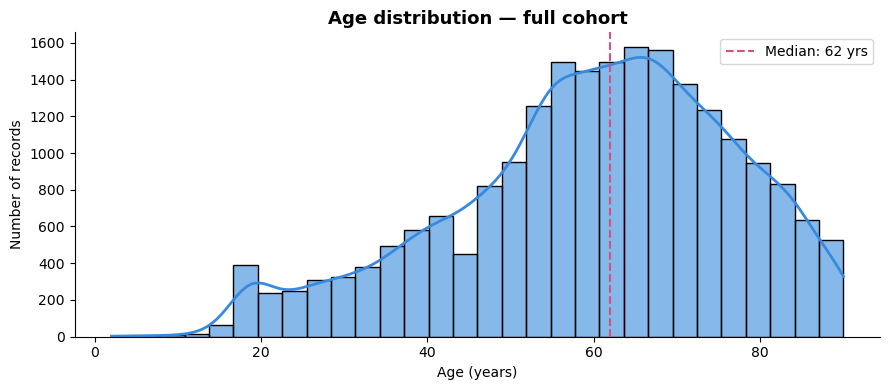

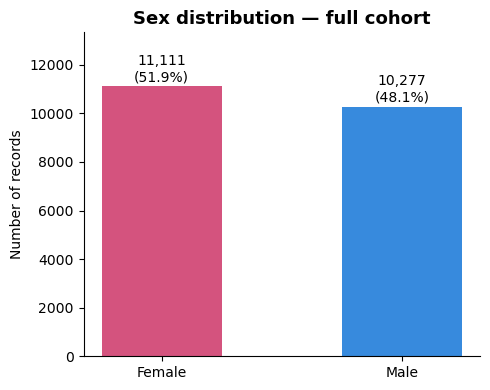

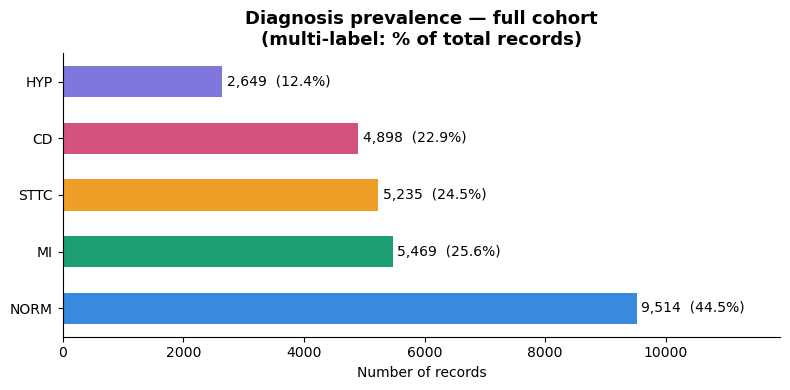

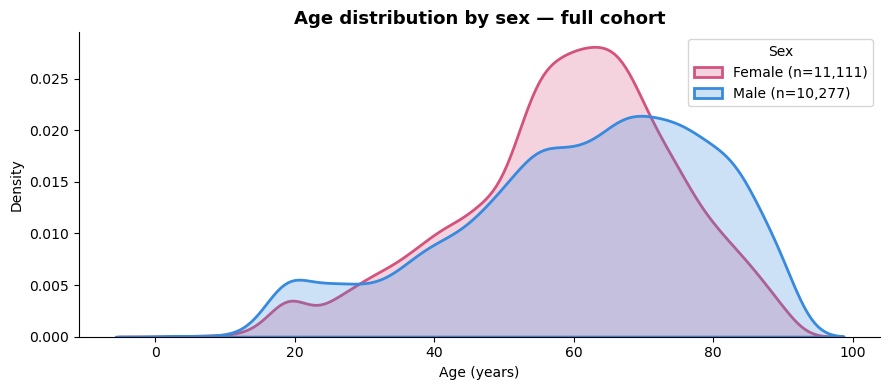

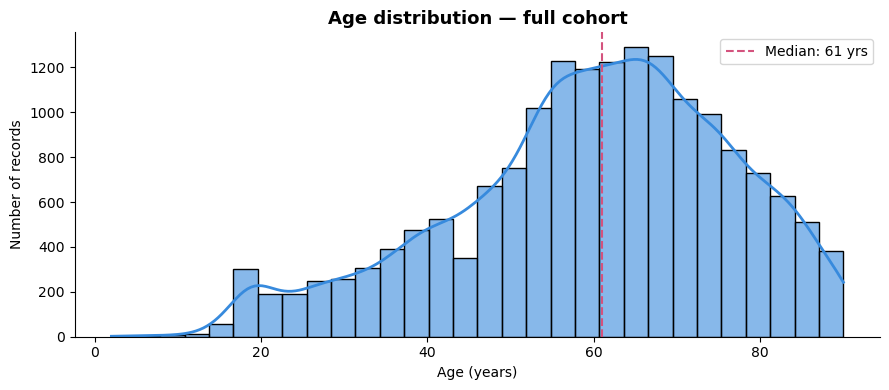

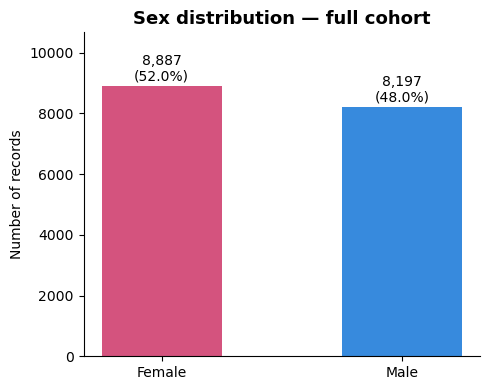

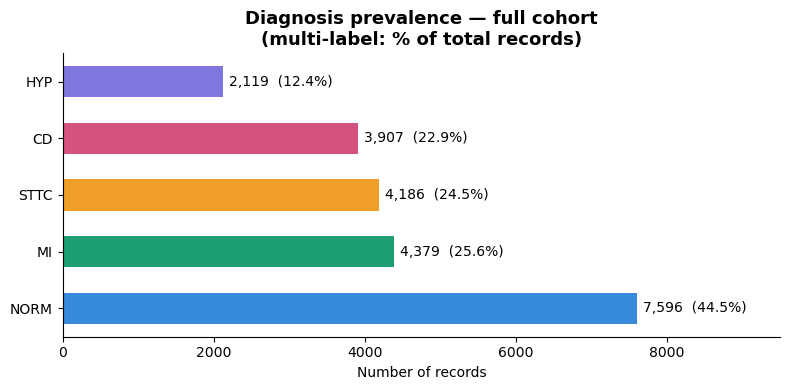

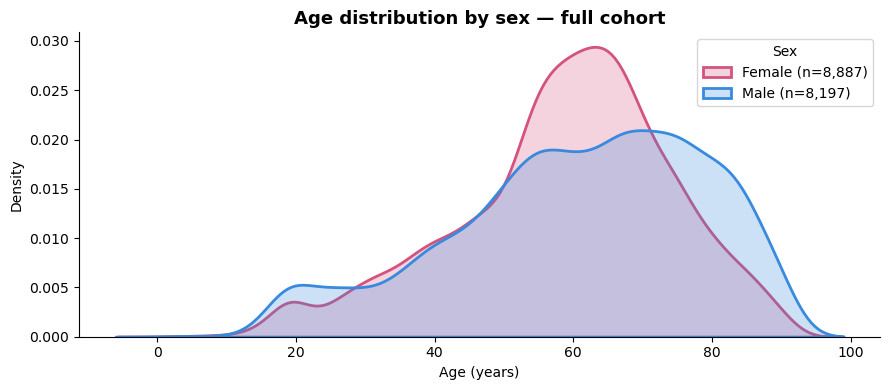

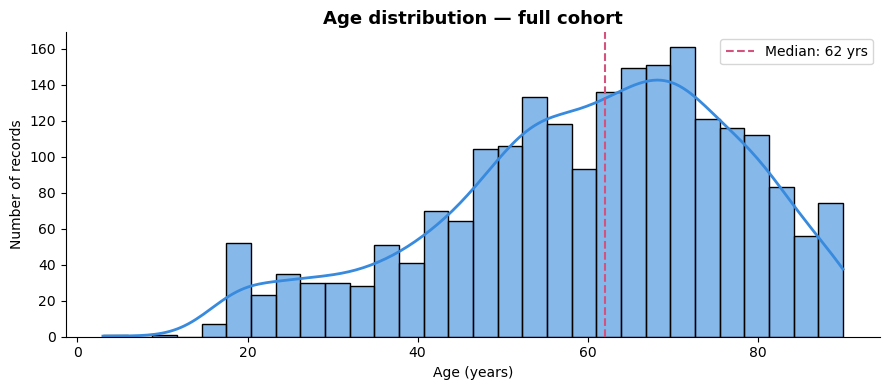

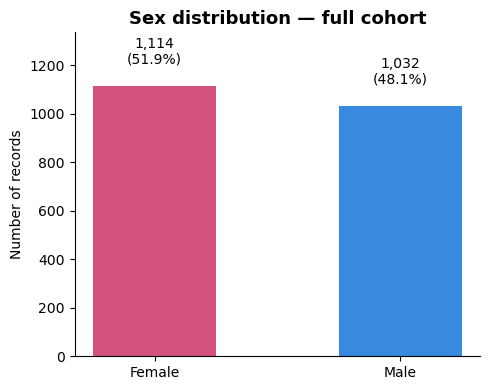

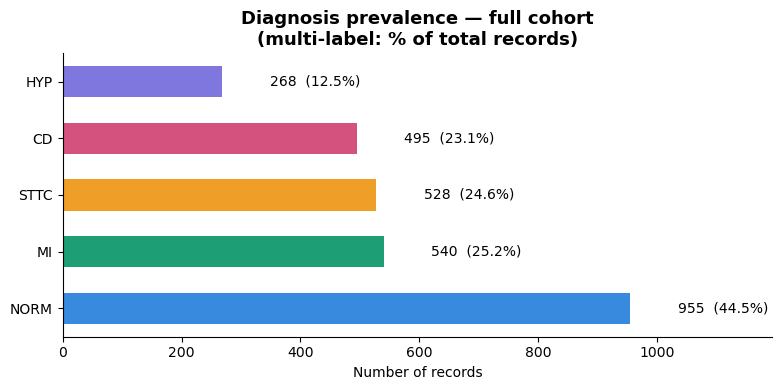

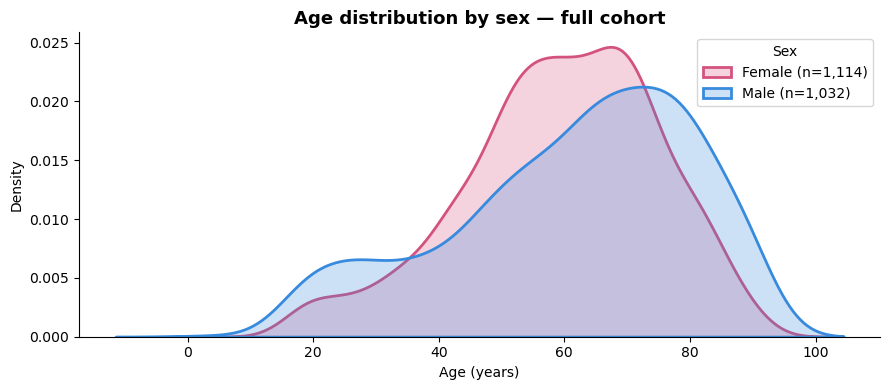

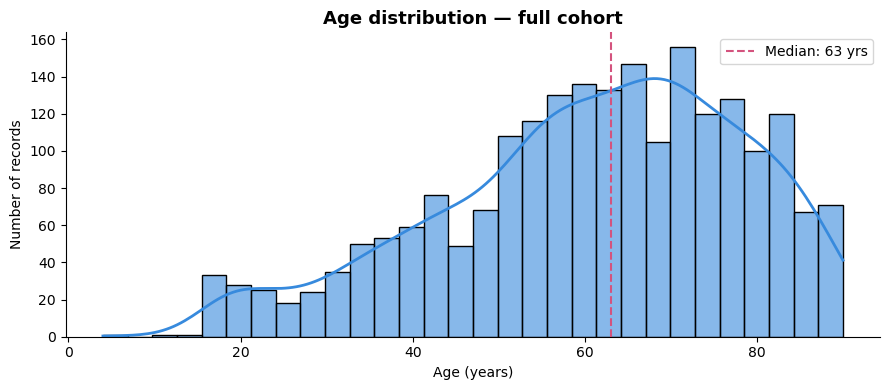

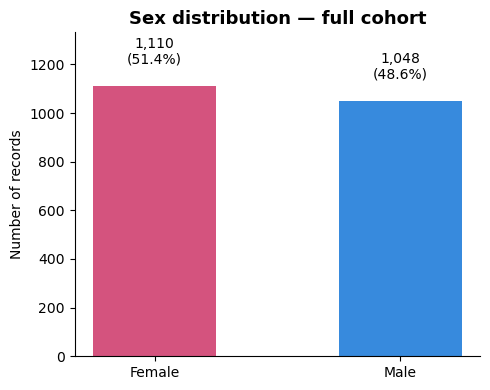

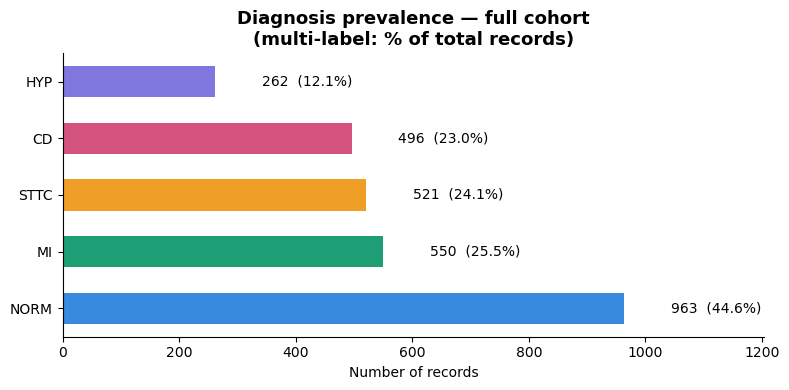

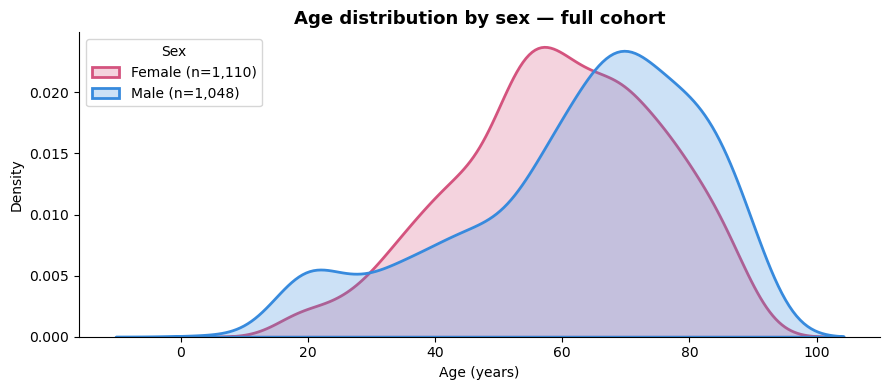

In [14]:
split_df = {
    'global': df,
    'train':  df[df['split'] == 'train'],
    'val':    df[df['split'] == 'val'],
    'test':   df[df['split'] == 'test'],
}

# ── Cohort summary stats + plots ──────────────────────────────────────────────
summary_tables = {}
cohort_plots   = {}

for key, df_split in split_df.items():
    print(f"{'='*60}")
    print(f"Split: {key.upper()}  ({len(df_split):,} records)")
    print(f"{'='*60}")

    summary_tables[key] = cohort_summary_stats(df_split)
    cohort_plots[key]   = plot_cohort_summary_stats(df_split)

    display(summary_tables[key])
    print("\n")

## Generate Table 2

In [15]:
def demographics_by_superclass(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute age and sex statistics stratified by diagnostic superclass.

    Args:
        df (pd.DataFrame): Dataframe containing 'superclass', 'age', and 'sex' columns.

    Returns:
        tuple:
            stats (pd.DataFrame): Formatted age and sex statistics per superclass.
            df_exploded (pd.DataFrame): Exploded dataframe used for downstream plotting.
    """
    df = df.copy()
    df.loc[df['age'] >= 89, 'age'] = 90

    # Explode so each row = one superclass label
    df_exploded = df[['patient_id', 'age', 'sex', 'superclass']].explode('superclass')
    df_exploded = df_exploded.dropna(subset=['superclass'])
    df_exploded['sex_label'] = df_exploded['sex'].map({0: 'Female', 1: 'Male'})  # must be here

    # Age statistics
    age_stats = (
        df_exploded.groupby('superclass')['age']
        .agg(
            mean_age='mean',
            sd_age='std',
            median_age='median',
            q1=lambda x: x.quantile(0.25),
            q3=lambda x: x.quantile(0.75),
            n='count'
        )
        .round(1)
    )

    # Sex statistics
    sex_stats = (
        df_exploded.groupby('superclass')['sex']
        .value_counts(normalize=True)
        .unstack()
        .reindex(columns=[0, 1], fill_value=0)  # 0 = Female, 1 = Male
        .rename(columns={0: 'female_pct', 1: 'male_pct'})
        .mul(100)
        .round(1)
    )

    # Sex counts (for the n in parentheses)
    sex_counts = (
        df_exploded.groupby('superclass')['sex']
        .value_counts()
        .unstack()
        .reindex(columns=[0, 1], fill_value=0)
        .rename(columns={0: 'female_n', 1: 'male_n'})
    )

    # Combine
    stats = age_stats.join(sex_stats).join(sex_counts)

    # Format columns
    stats['N (label count)'] = stats['n'].apply(lambda x: f"{x:,}")
    stats['Mean ± SD']       = stats.apply(lambda r: f"{r['mean_age']} ± {r['sd_age']}", axis=1)
    stats['Median (IQR)']    = stats.apply(lambda r: f"{r['median_age']} ({r['q1']}–{r['q3']})", axis=1)
    stats['Female']          = stats.apply(lambda r: f"{r['female_n']:,.0f} ({r['female_pct']}%)", axis=1)
    stats['Male']            = stats.apply(lambda r: f"{r['male_n']:,.0f} ({r['male_pct']}%)", axis=1)

    return stats[['N (label count)', 'Mean ± SD', 'Median (IQR)', 'Female', 'Male',
                  'female_pct', 'male_pct', 'n']], df_exploded

def plot_demographics_by_superclass(stats: pd.DataFrame, df_exploded: pd.DataFrame) -> dict:
    """
    Visualize demographics stratified by diagnostic superclass.
    Consumes outputs from demographics_by_superclass().

    Args:
        stats (pd.DataFrame): Formatted stats table from demographics_by_superclass().
        df_exploded (pd.DataFrame): Exploded dataframe from demographics_by_superclass().

    Returns:
        dict: Dictionary of matplotlib figures keyed by plot name.
    """
    demographic_stat_plots = {}

    # Define colors and orders
    CLASS_ORDER = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
    COLORS      = ['#378ADD', '#1D9E75', '#EF9F27', '#D4537E', '#7F77DD']
    PALETTE     = dict(zip(CLASS_ORDER, COLORS))
    SEX_PALETTE = {'Female': '#D4537E', 'Male': '#378ADD'}
    
    # -- 1. Age Distribution by Superclass (Violin + Boxplot) --
    fig1, ax1 = plt.subplots(figsize=(10,5), facecolor='white')
    sns.violinplot(
        data=df_exploded, x='superclass', y='age', hue='superclass',
        order=CLASS_ORDER, palette=PALETTE,
        alpha=0.4, ax=ax1
    )
    sns.boxplot(
        data=df_exploded, x='superclass', y='age',
        order=CLASS_ORDER, width=0.15, 
        color='white', linewidth=1.2, 
        ax=ax1
    )
    ax1.set_title('Age distribution by diagnostic superclass', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Superclass'); ax1.set_ylabel('Age (years)')
    ax1.set_ylim(0, 95)
    sns.despine(ax=ax1)
    fig1.tight_layout()
    demographic_stat_plots['age_violin'] = fig1

    # -- 2. Sex breakdown by superclass (stacked horizontal bar) --
    sex_pct = (
        stats.reindex(CLASS_ORDER)[['female_pct', 'male_pct']]
        .rename(columns={'female_pct': 'Female', 'male_pct': 'Male'})
    )
    fig2, ax2 = plt.subplots(figsize=(8, 4))
    sex_pct.plot(
        kind='barh', stacked=True,
        color=[SEX_PALETTE['Female'], SEX_PALETTE['Male']],
        ax=ax2, edgecolor='none'
    )
    ax2.axvline(50, color='white', linewidth=1.2, linestyle='--')
    ax2.set_xlabel('Percentage (%)'); ax2.set_ylabel('')
    ax2.set_title('Sex distribution by diagnostic superclass', fontsize=13, fontweight='bold')
    ax2.legend(title='Sex', bbox_to_anchor=(1.01, 1), loc='upper left')
    ax2.set_xlim(0, 100)
    sns.despine(ax=ax2)
    fig2.tight_layout()
    demographic_stat_plots['sex_stacked_bar'] = fig2

    # -- 3. Record counts per superclass --
    counts = stats.reindex(CLASS_ORDER)['n']
    fig3, ax3 = plt.subplots(figsize=(8, 4))
    bars = ax3.barh(CLASS_ORDER, counts.values, 
                    color=COLORS, edgecolor='none', height=0.55)
    for bar, val in zip(bars, counts.values):
        ax3.text(bar.get_width() + 80, bar.get_y() + bar.get_height() / 2,
                 f'{val:,}', va='center', fontsize=10)
    ax3.set_xlabel('Number of records (label count)')
    ax3.set_title('Record counts per diagnostic superclass', fontsize=13, fontweight='bold')
    ax3.set_xlim(0, counts.max() * 1.15)
    sns.despine(ax=ax3)
    fig3.tight_layout()
    demographic_stat_plots['class_counts'] = fig3

    # ── 4. Age × sex interaction per superclass (grouped boxplot) ─────────────
    fig4, ax4 = plt.subplots(figsize=(10, 5))
    sns.boxplot(
        data=df_exploded, x='superclass', y='age', hue='sex_label',
        order=CLASS_ORDER, palette=SEX_PALETTE,
        width=0.5, fliersize=2, linewidth=1.0, ax=ax4
    )
    ax4.set_title('Age by superclass and sex', fontsize=13, fontweight='bold')
    ax4.set_xlabel('Superclass'); ax4.set_ylabel('Age (years)')
    ax4.legend(title='Sex', bbox_to_anchor=(1.01, 1), loc='upper left')
    sns.despine(ax=ax4)
    fig4.tight_layout()
    demographic_stat_plots['age_sex_interaction'] = fig4

    return demographic_stat_plots

Split: global (21,388 records)
           N (label count)    Mean ± SD      Median (IQR)         Female  \
superclass                                                                 
CD                   4,898  66.0 ± 15.4  68.0 (57.0–77.0)  2,999 (61.2%)   
HYP                  2,649  66.4 ± 14.2  68.0 (58.0–77.0)  1,520 (57.4%)   
MI                   5,469  66.8 ± 12.9  67.0 (58.0–76.0)  3,407 (62.3%)   
NORM                 9,514  52.2 ± 17.3  54.0 (40.0–65.0)  4,386 (46.1%)   
STTC                 5,235  66.9 ± 13.9  68.0 (58.0–77.0)  2,566 (49.0%)   

                     Male  female_pct  male_pct     n  
superclass                                             
CD          1,899 (38.8%)        61.2      38.8  4898  
HYP         1,129 (42.6%)        57.4      42.6  2649  
MI          2,062 (37.7%)        62.3      37.7  5469  
NORM        5,128 (53.9%)        46.1      53.9  9514  
STTC        2,669 (51.0%)        49.0      51.0  5235  
____________________________________________

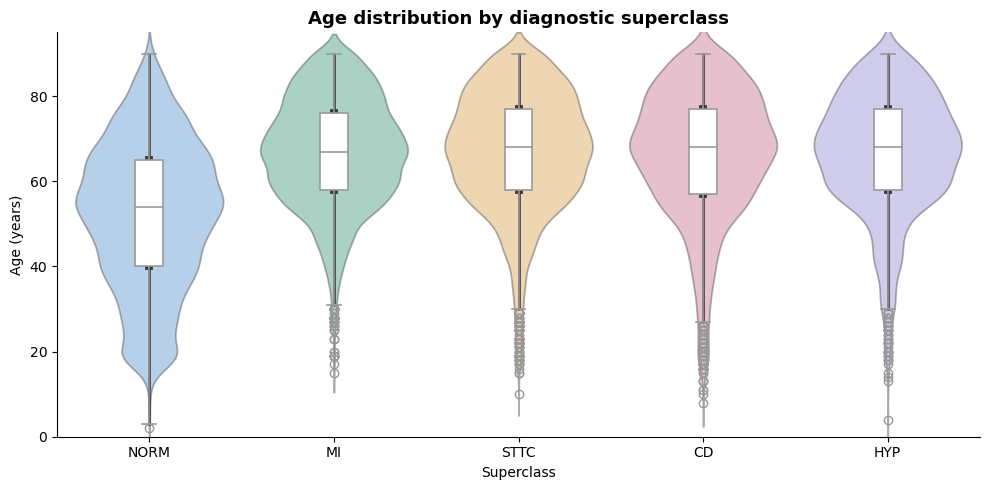

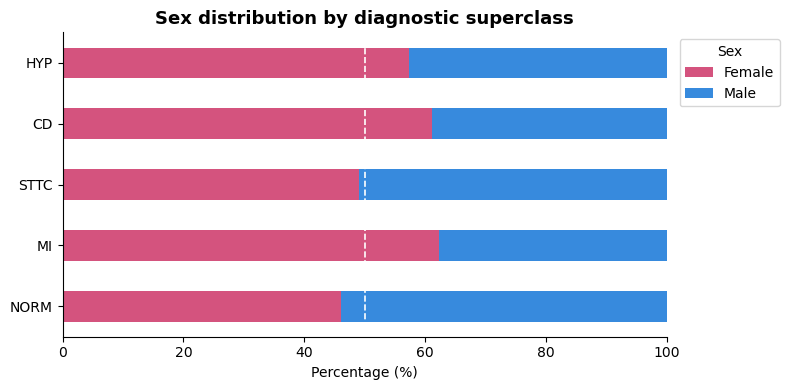

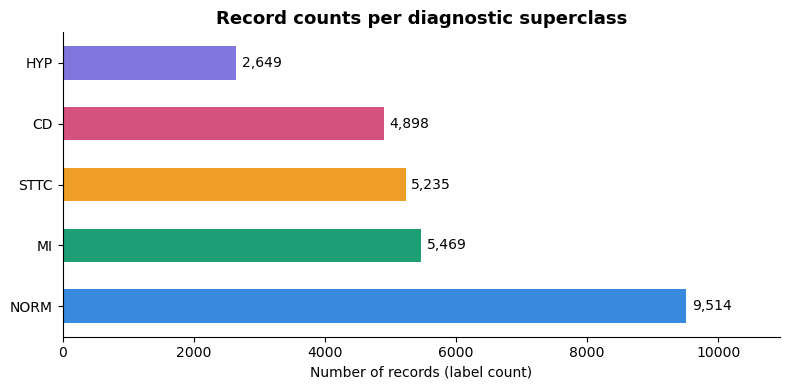

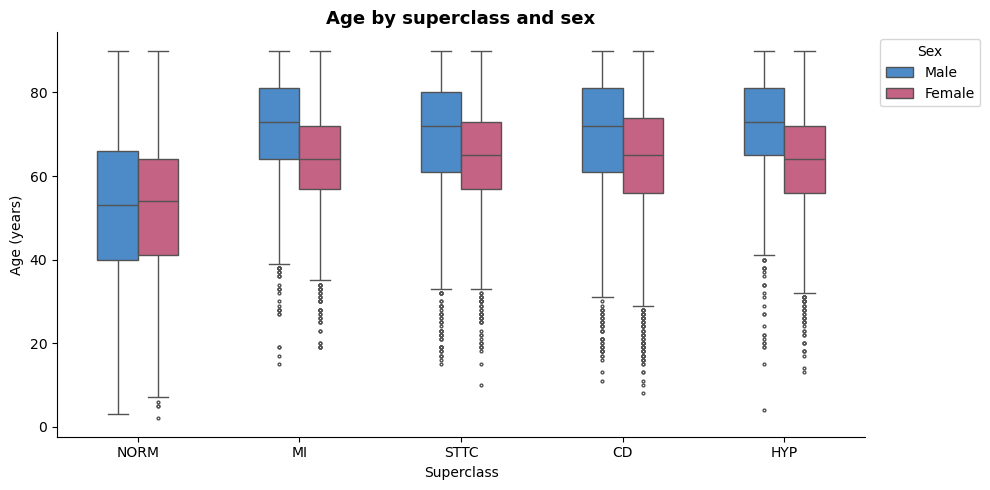

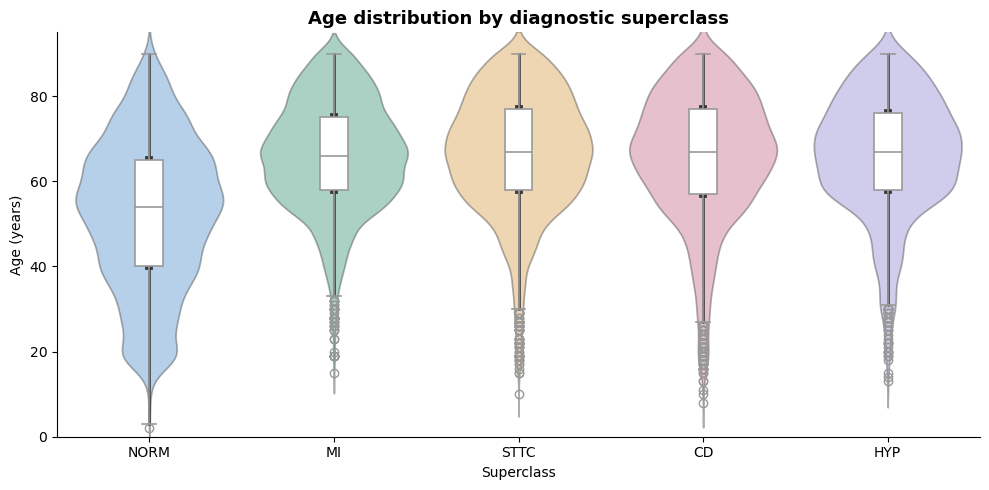

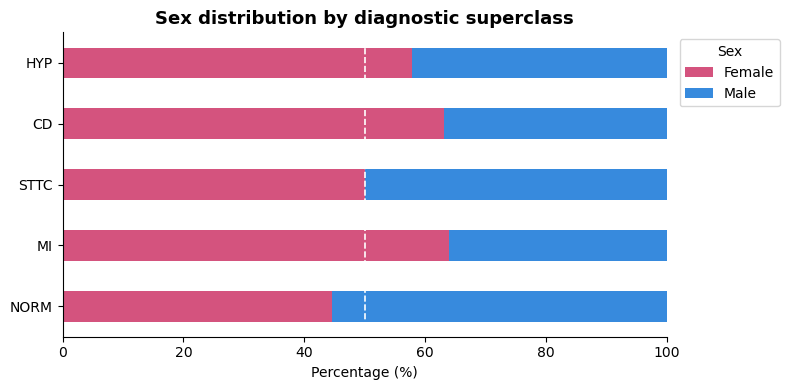

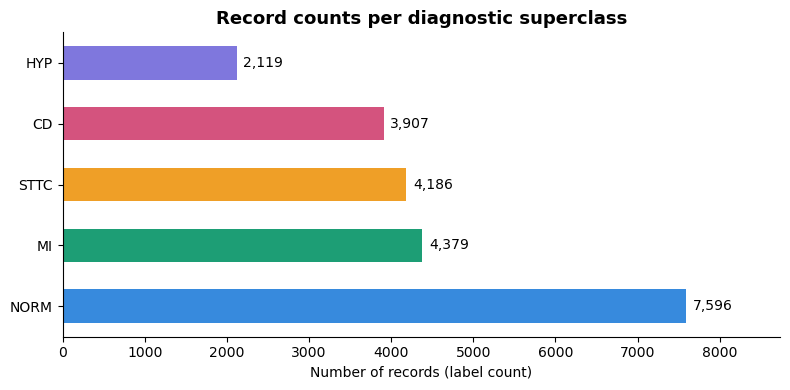

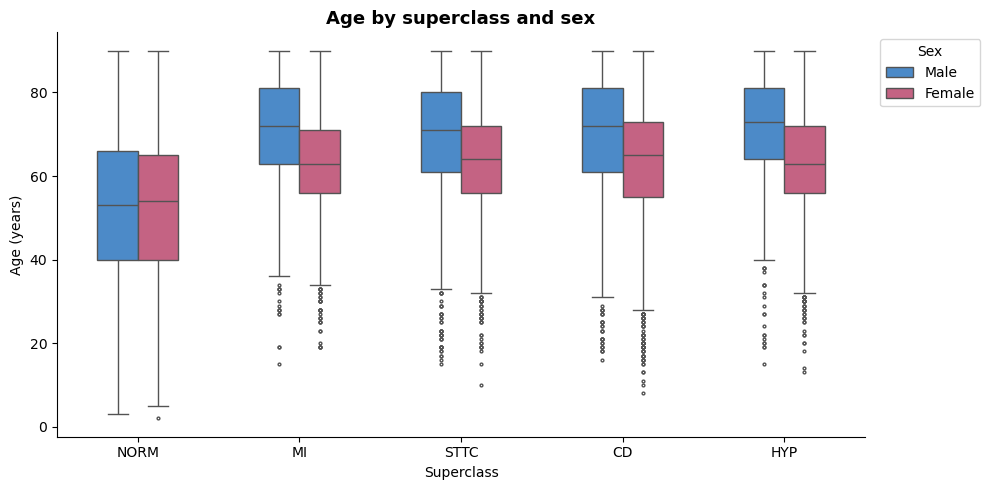

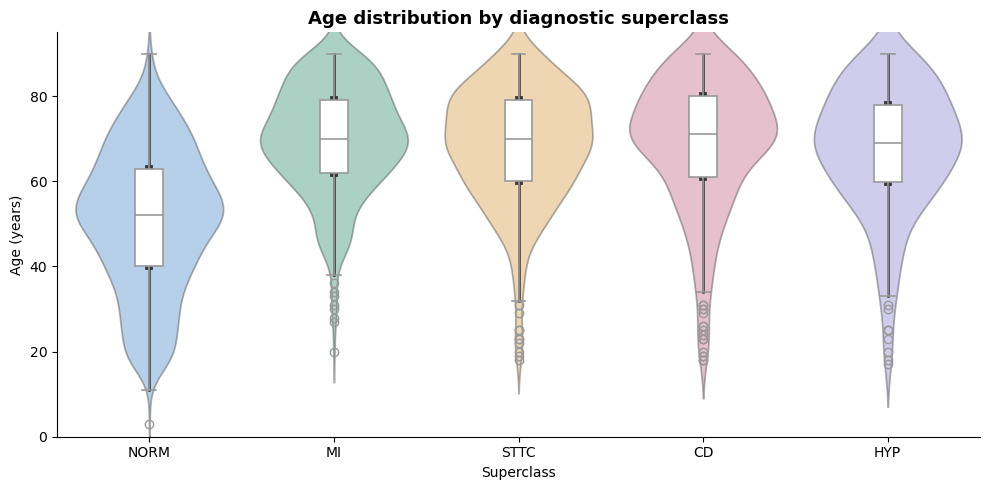

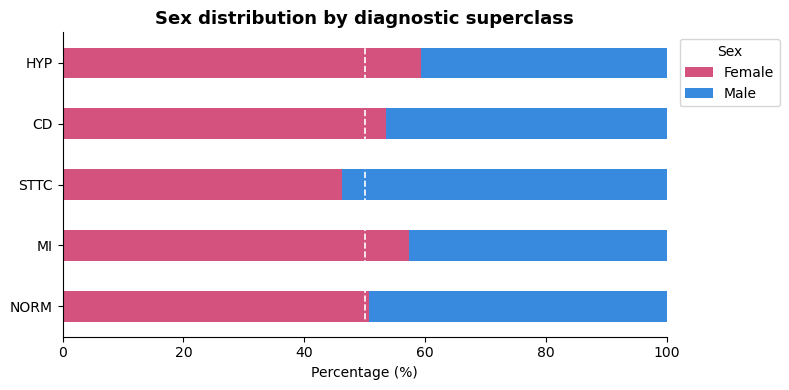

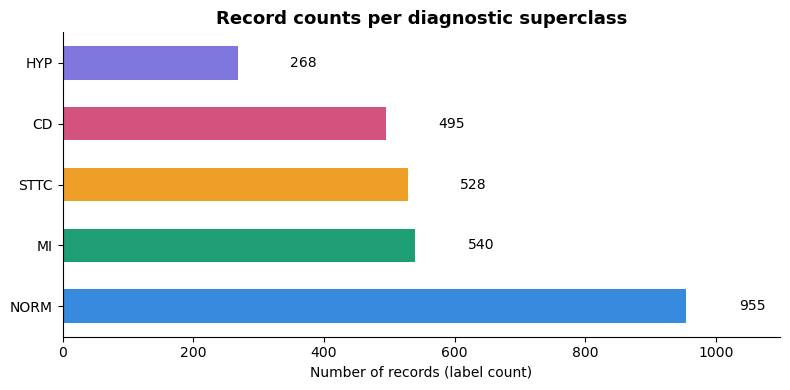

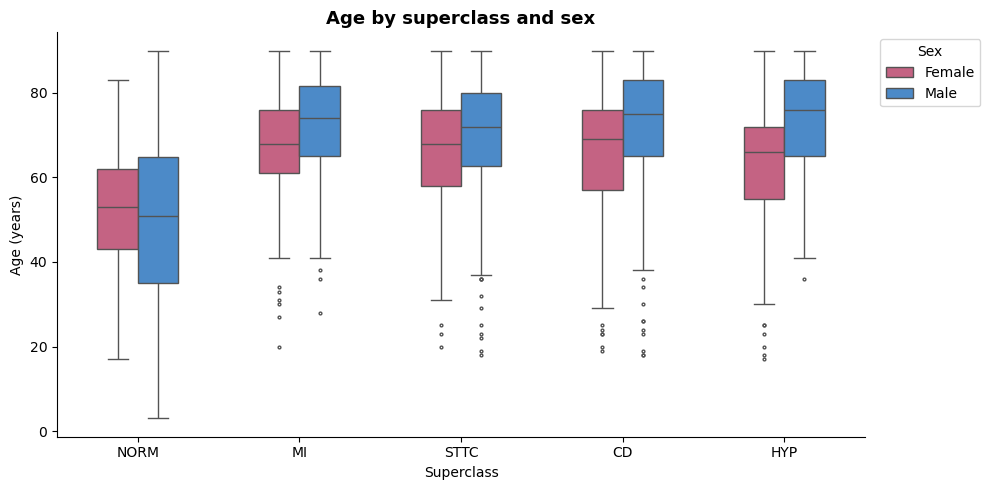

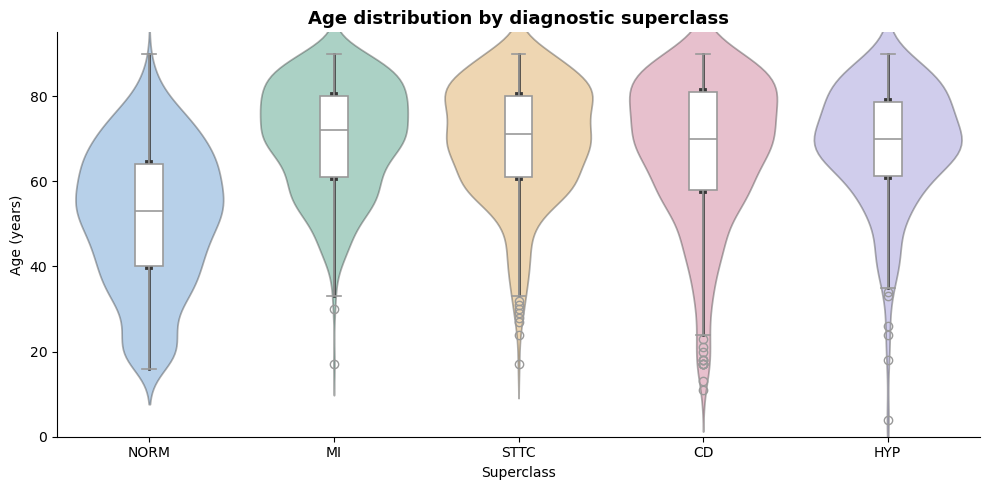

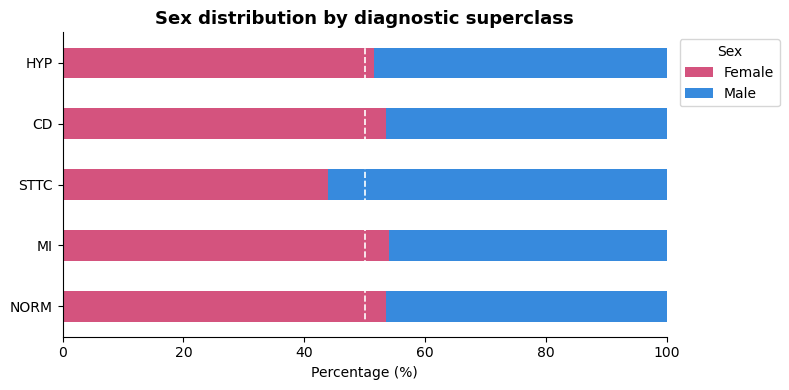

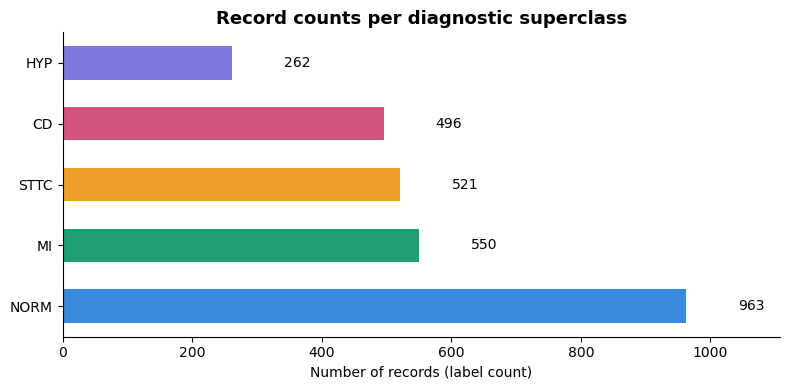

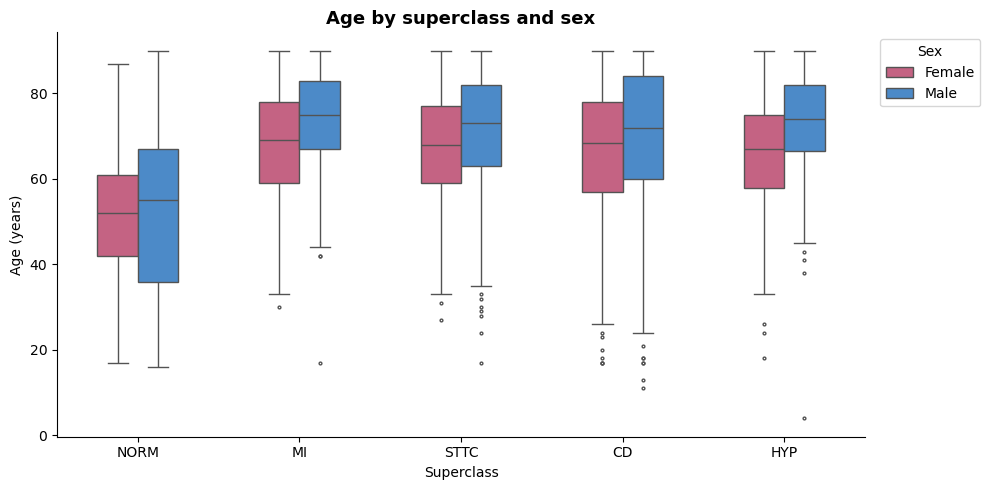

In [16]:
# View the superclass breakdown globally, train, test, val\
# Build split dictionary
split_df = {
    'global': df,
    'train':  df[df['split'] == 'train'],
    'val':    df[df['split'] == 'val'],
    'test':   df[df['split'] == 'test'],
}

# Loop through all splits and display stats
plots_splits = {}
for key, df_split in split_df.items():
    print(f"Split: {key} ({len(df_split):,} records)")
    
    stats, df_exploded = demographics_by_superclass(df_split)
    plots_splits[key]  = plot_demographics_by_superclass(stats, df_exploded)

    print(stats)
    print("_" * 100)
    print("\n")


### Compute Co-occurance 

In [17]:
from itertools import combinations

# Count how often each pair co-occurs 
pairs = []
for labels in df['superclass']:
    for a, b in combinations(sorted(labels), 2):
        pairs.append((a,b))

# Create dataframe storing co-occurance
cooc = pd.DataFrame(pairs, columns=["A", "B"]).value_counts().reset_index()

In [18]:
cooc

,A,B,count
0,CD,MI,1794
1,HYP,STTC,1509
2,MI,STTC,1339
3,CD,STTC,1066
4,HYP,MI,818
5,CD,HYP,787
6,CD,NORM,415
7,NORM,STTC,33
8,HYP,NORM,5
9,MI,NORM,1


In [19]:
# Pivot to square matrix
cooc_matrix = cooc.pivot(index='A', columns='B', values='count').fillna(0)

# Make it symmetric — currently only has (A,B) not (B,A) since combinations() is ordered
cooc_matrix = cooc_matrix.reindex(index=CLASS_ORDER, columns=CLASS_ORDER, fill_value=0)
cooc_matrix = cooc_matrix + cooc_matrix.T  # mirror across diagonal

# Add diagonal — how many records contain each class at all
all_classes  = [cls for sublist in df['superclass'] for cls in sublist]
class_counts = pd.Series(all_classes).value_counts()
for cls in CLASS_ORDER:
    cooc_matrix.loc[cls, cls] = class_counts.get(cls, 0)

In [20]:
def plot_cooccurrence(cooc_matrix: pd.DataFrame) -> plt.Figure:
    """
    Plot label co-occurrence heatmap with upper triangle masked.

    Args:
        cooc_matrix (pd.DataFrame): Square co-occurrence matrix.

    Returns:
        plt.Figure
    """
    # Normalize by row (% of row class records that also have column class)
    cooc_pct = cooc_matrix.div(cooc_matrix.values.diagonal(), axis=0) * 100

    # Mask upper triangle (excluding diagonal)
    mask = np.triu(np.ones_like(cooc_pct, dtype=bool), k=1)

    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(
        cooc_pct,
        mask=mask,
        annot=True, fmt='.1f',
        cmap='Reds',
        vmin=0, vmax=100,
        linewidths=0.5,
        linecolor='white',
        ax=ax
    )
    ax.set_title('Label co-occurrence\n(% of row class records also having column class)',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel(''); ax.set_ylabel('')
    fig.tight_layout()
    return fig

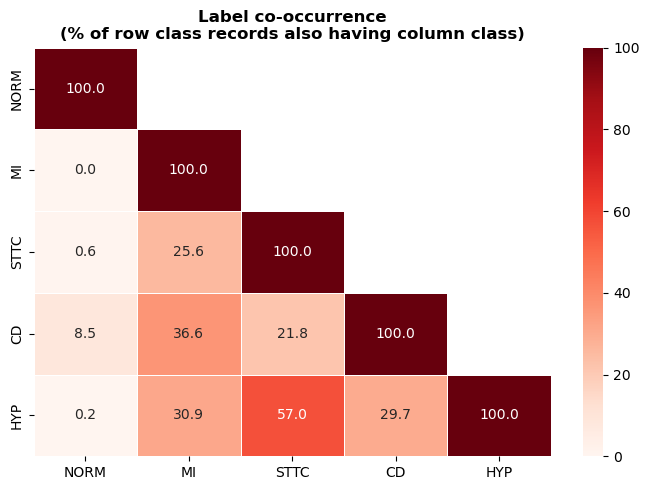

In [21]:
fig = plot_cooccurrence(cooc_matrix)

## Signal EDA

In addition to demographics of the study cohort there is also EDA on the ECG Signal. We will explore Power Spectral Density and the waveforms.

All Signal EDA will use 100 Hz 

In [22]:
# Define a function to load a sample per diagnostic superclass to visualize all of them
def load_sample_per_class(df: pd.DataFrame, path: Path, fs: int = 100) -> dict:
    """
    Load one representative ECG record per diagnostic Superclass. 

    Args:
        df (pd.DataFrame): Dataframe with 'superclass', 'split', and 'filename_lr' columns.
        path (str): Path to the PTB-XL root directory.
        fs (int): Sampling frequency - 100 or 500 Hz.
    
    Returns:
        dict: Keys are superclass names, values are (timesteps, 12) numpy arrays.
    """
    key = 'filename_lr' if fs == 100 else 'filename_hr'
    train_df = df[df['split'] == 'train']

    samples = {}
    for cls in CLASS_ORDER:
        # Find records that contain the class and only that class
        mask = train_df['superclass'].apply(lambda x: cls in x and len(x) == 1)
        subset = train_df[mask]

        if len(subset) == 0:
            # Fall back to any record containing this class
            mask = train_df['superclass'].apply(lambda x: cls in x)
            subset = train_df[mask]
        
        # Take the first record
        row = subset.iloc[0]
        signal, _ = wfdb.rdsamp(str(path / row[key]))
        samples[cls] = np.array(signal) # shape: (1000, 12) at 100 Hz
    
    return samples

In [23]:
samples = load_sample_per_class(df, DATA, fs=100)

# Sanity Check
for cls, sig in samples.items():
    print(f"{cls}: shape={sig.shape}, min={sig.min():.3f}, max={sig.max():.3f}")

NORM: shape=(1000, 12), min=-1.377, max=0.706
MI: shape=(1000, 12), min=-1.210, max=0.901
STTC: shape=(1000, 12), min=-1.805, max=0.779
CD: shape=(1000, 12), min=-2.933, max=1.879
HYP: shape=(1000, 12), min=-2.137, max=3.652


In [24]:
# Set up an ECG plot function 
LEADS = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
def plot_ecg(signal: np.ndarray, title: str, fs: int = 100) -> plt.Figure:
    """
    Plot a standard 12-lead ECG from a (timesteps, 12) numpy array.

    Args:
        signal (np.ndarray): ECG signal of shape (timsteps, 12)
        title (str): Plot title
        fs (int): Sampling frequency in Hz
    
    Returns:
        plt.Figure
    """
    t   = np.arange(signal.shape[0]) / fs  # time axis in seconds
    fig, axes = plt.subplots(12, 1, figsize=(14, 16), sharex=True)

    for i, (ax, lead) in enumerate(zip(axes, LEADS)):
        ax.plot(t, signal[:, i], linewidth=0.7, color='#1a1a1a')
        ax.set_ylabel(lead, fontsize=9, rotation=0, labelpad=28, va='center')

        # Centre the y-axis around the signal mean for consistent visual scale
        mean  = signal[:, i].mean()
        ax.set_ylim(mean - 1.5, mean + 1.5)

        # Only show x-axis on bottom plot
        sns.despine(ax=ax, bottom=(i < 11))

    axes[-1].set_xlabel('Time (s)')
    fig.suptitle(title, fontsize=13, fontweight='bold', y=1.001)
    fig.tight_layout()
    return fig


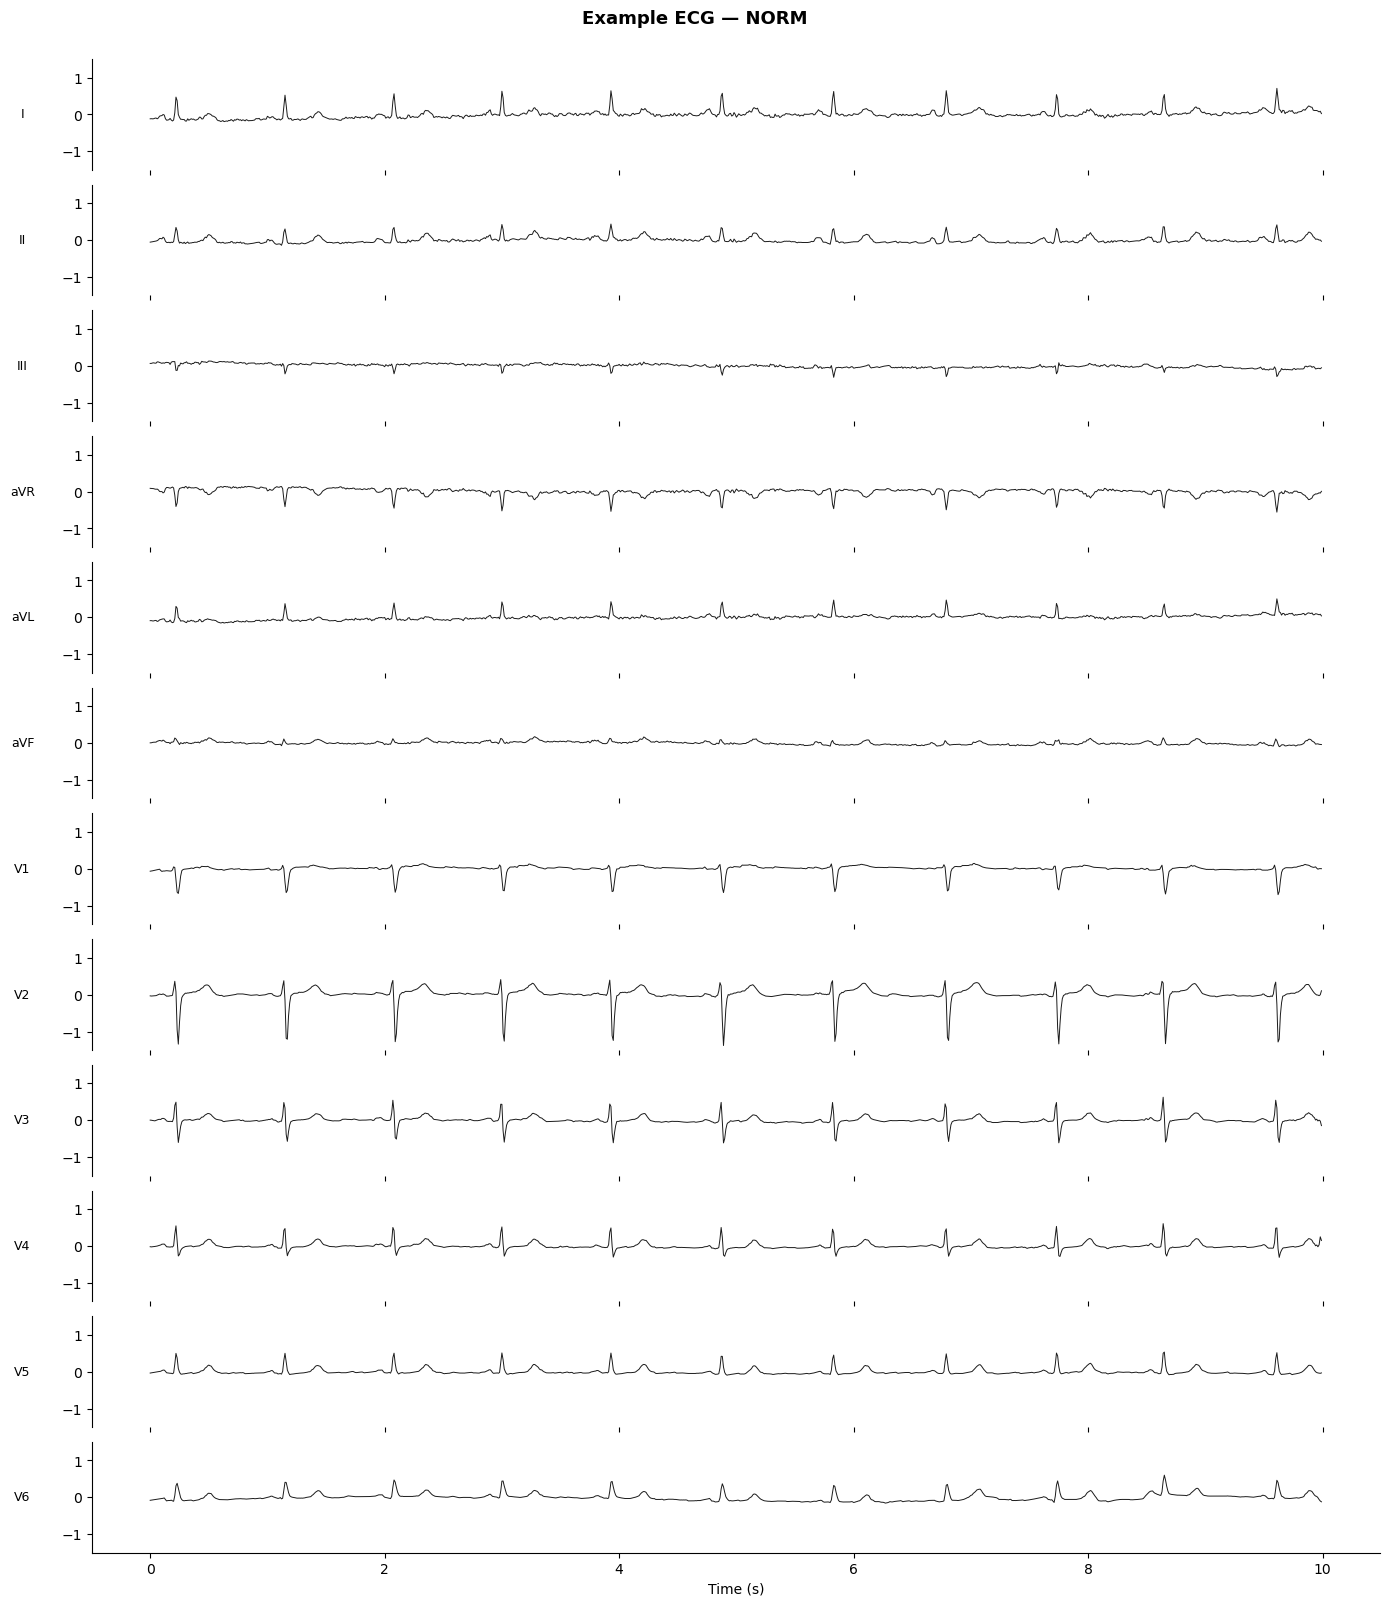

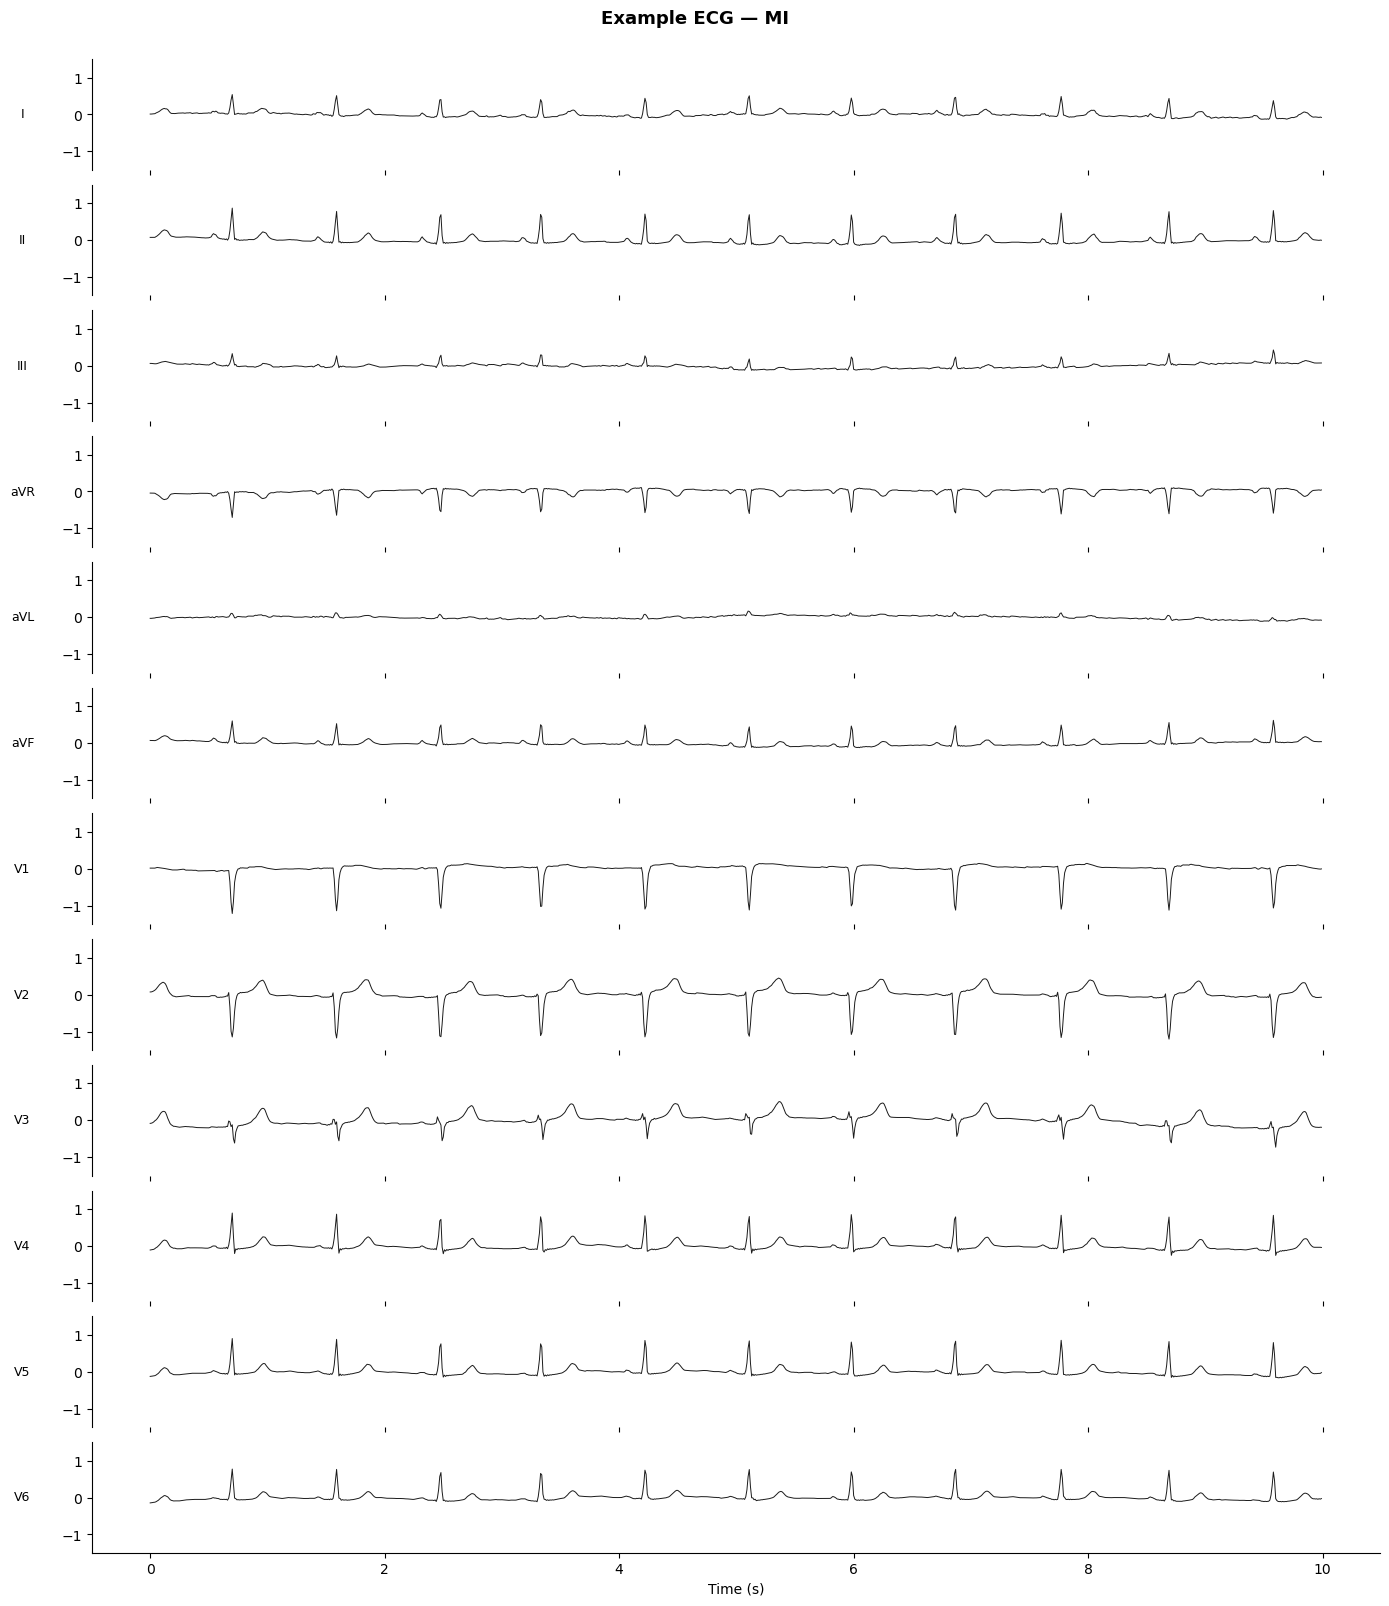

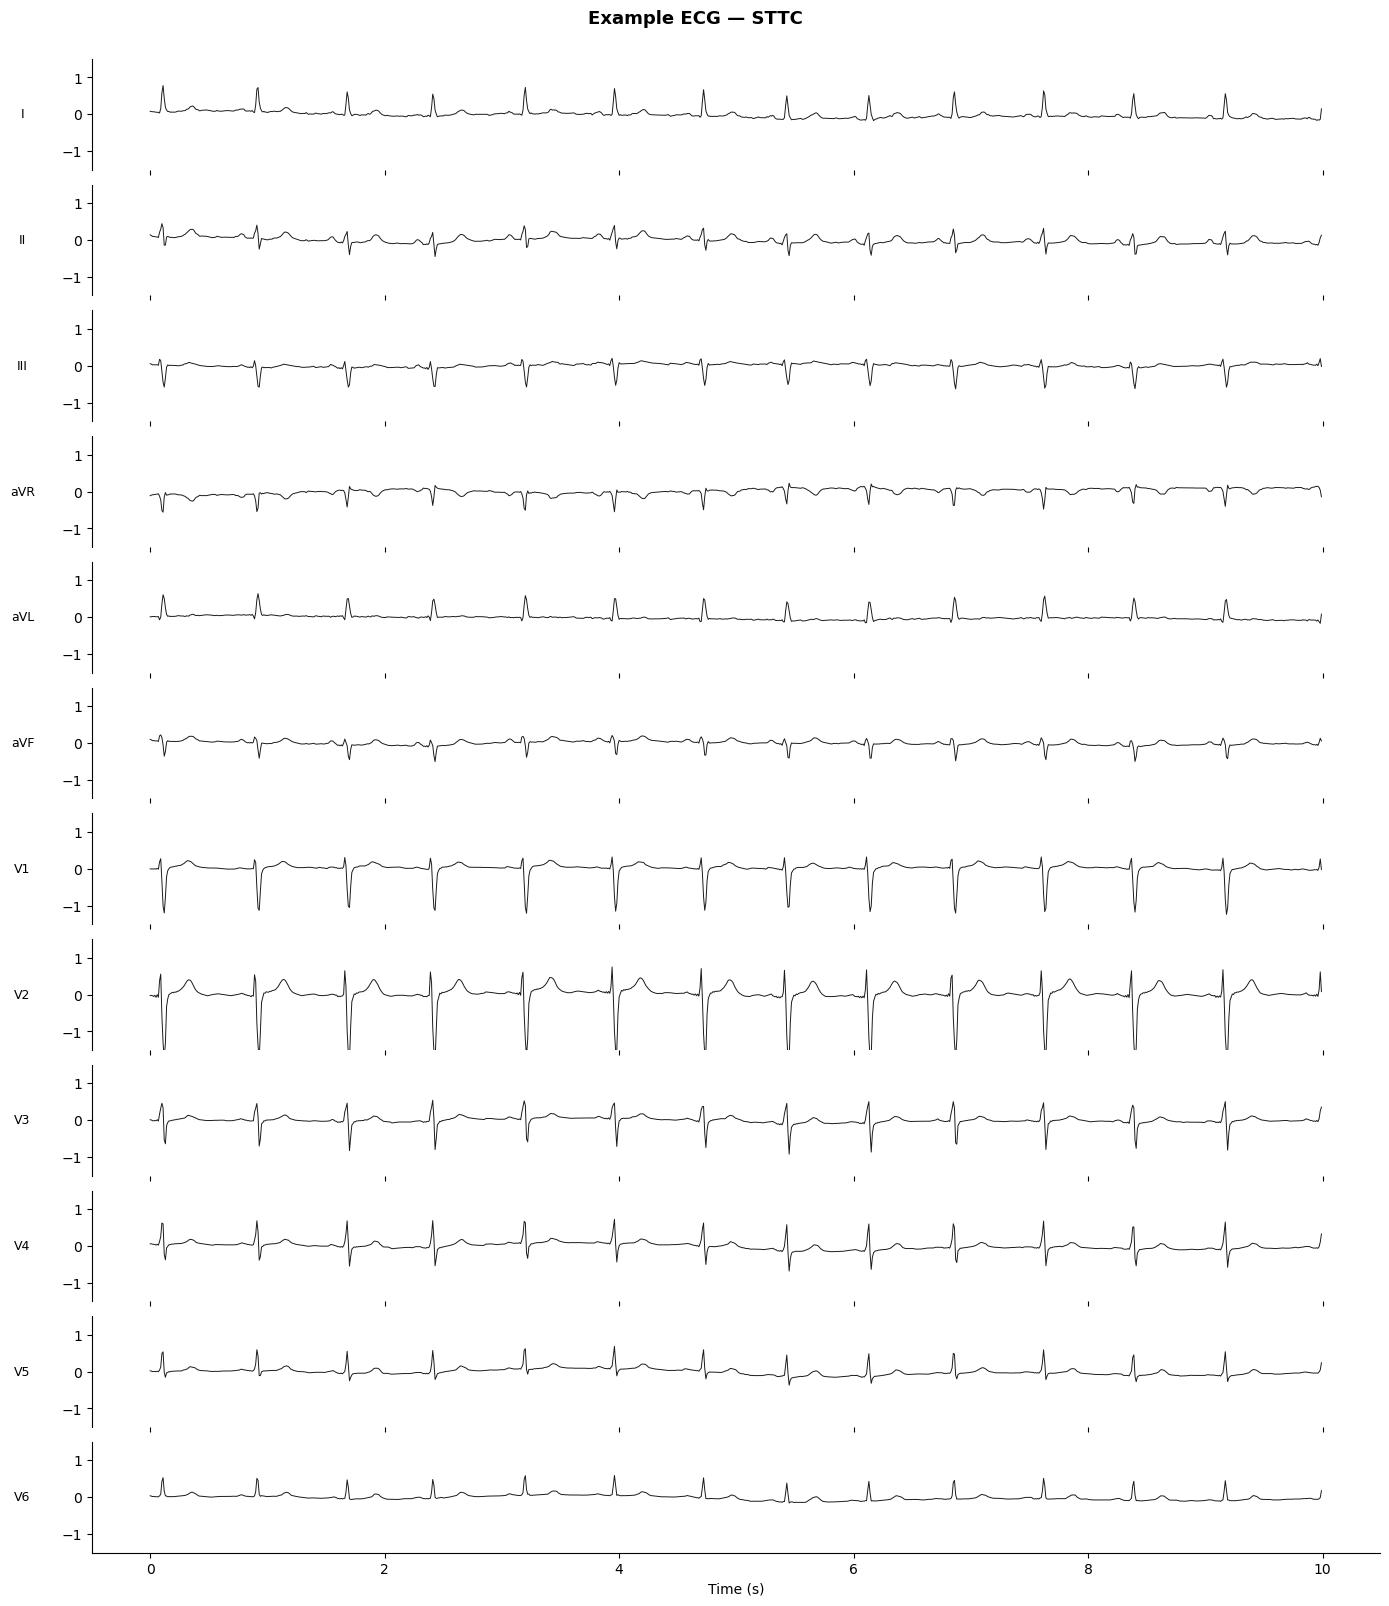

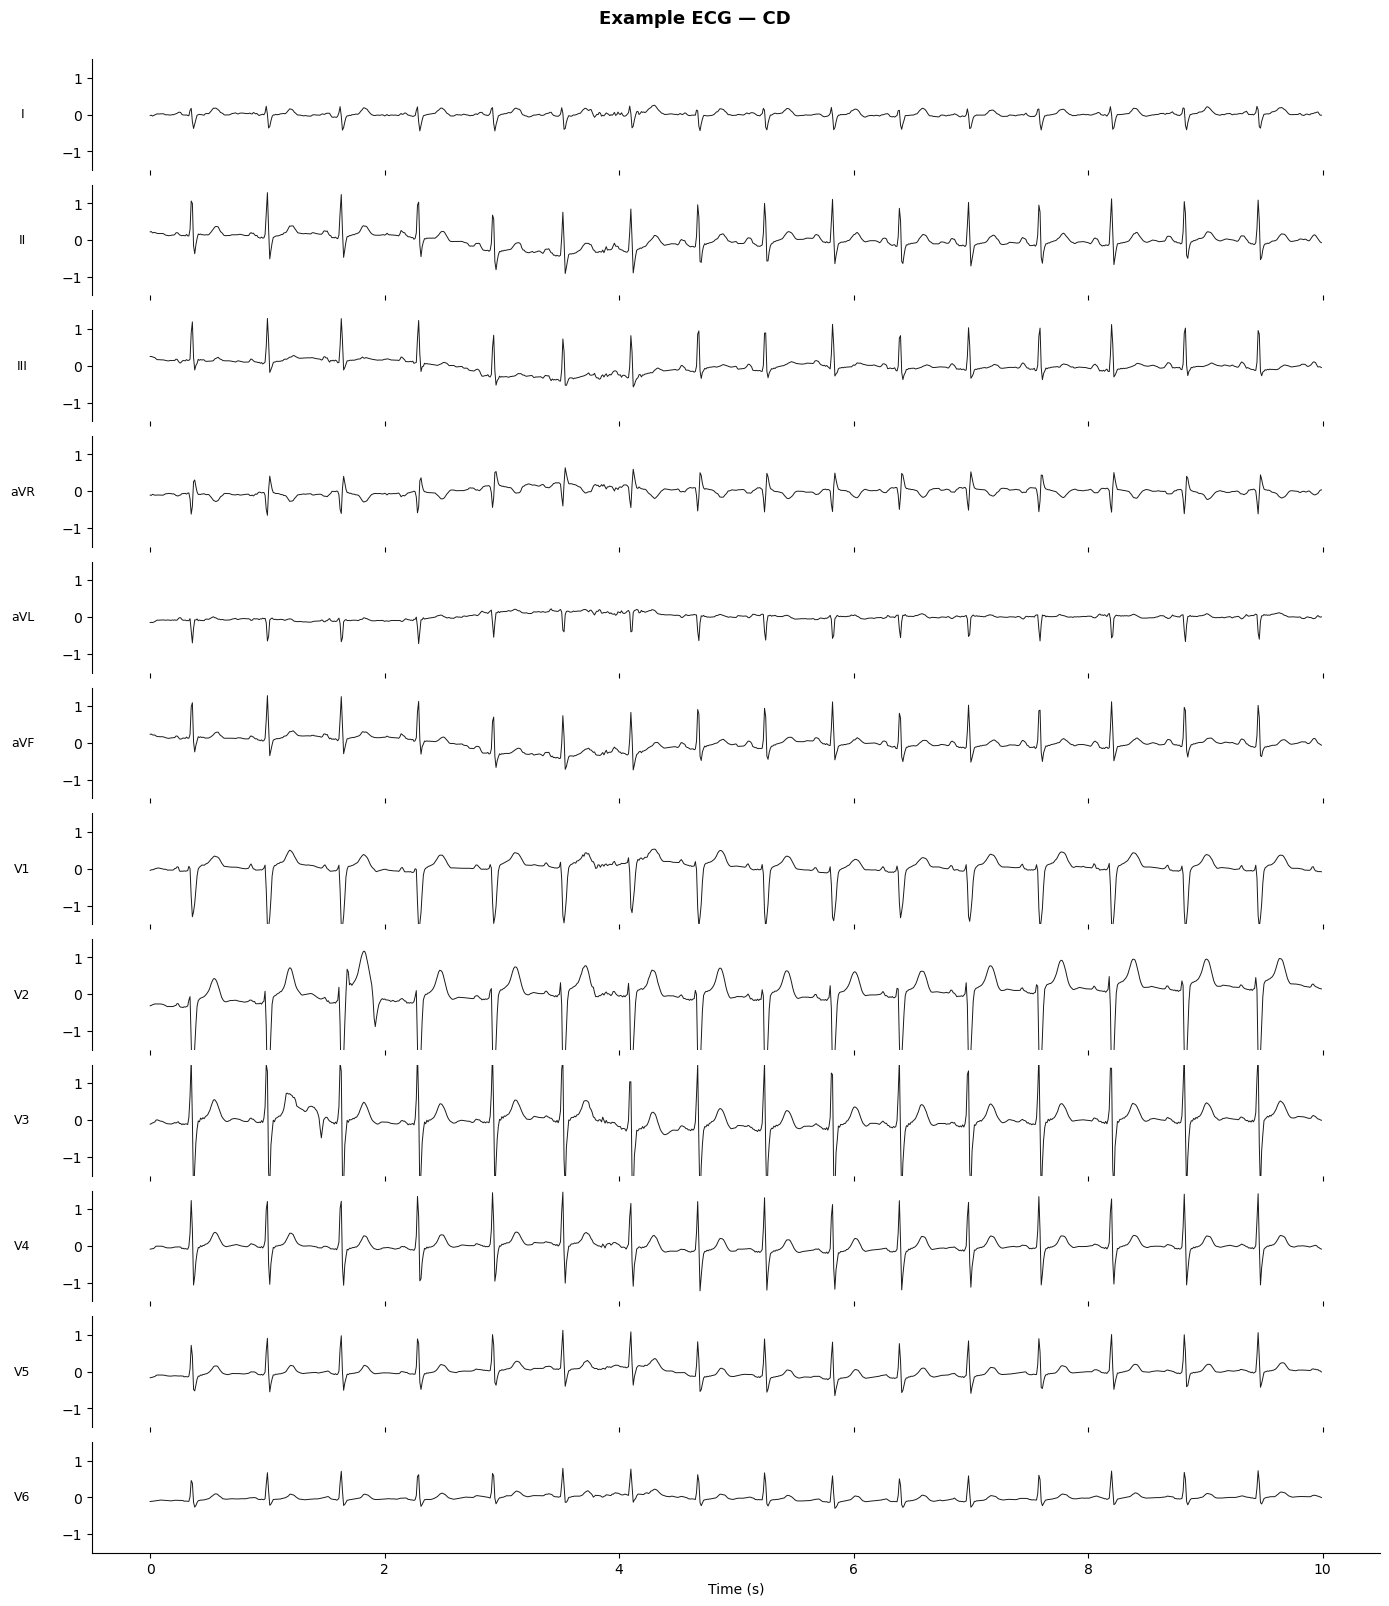

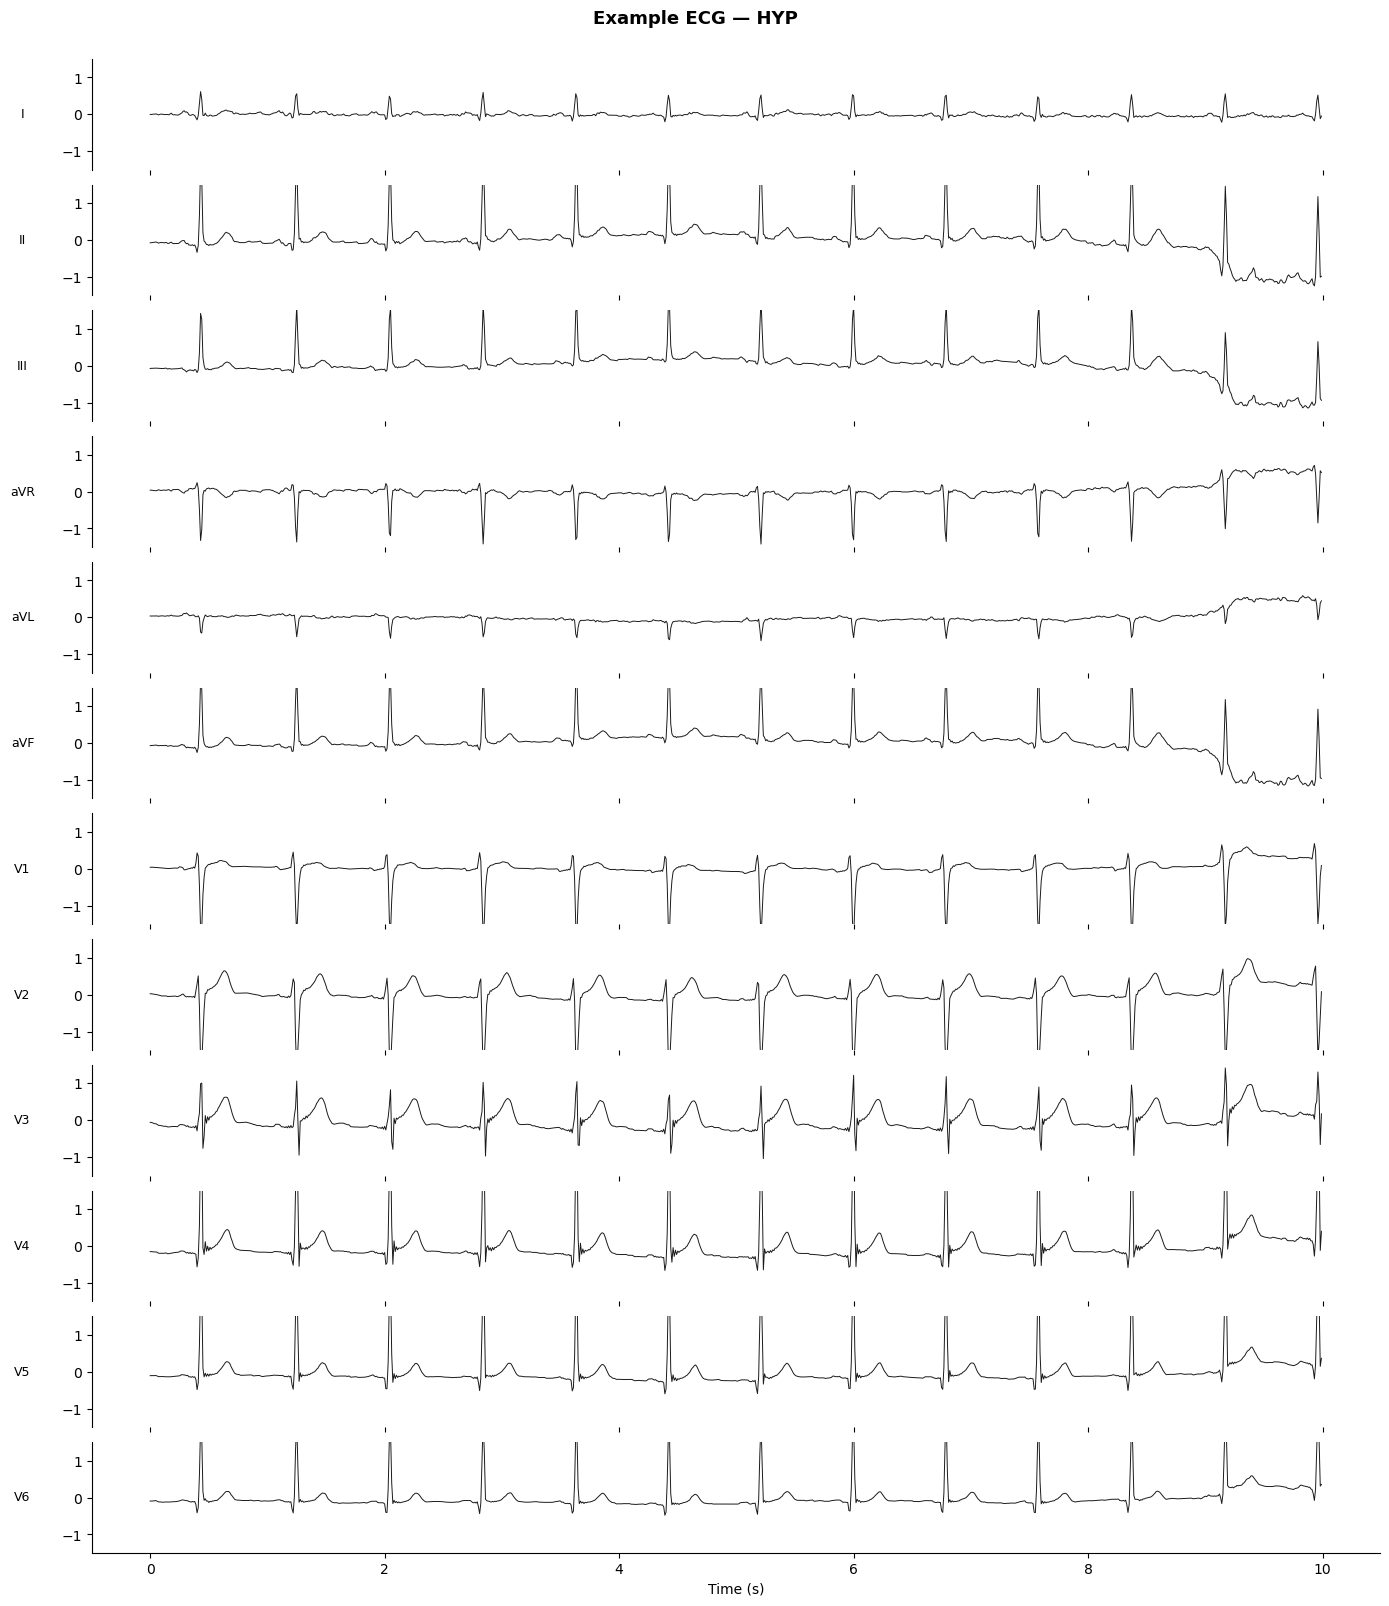

In [25]:
ecg_plots = {}
for cls, signal in samples.items():
    fig = plot_ecg(signal, title=f'Example ECG — {cls}', fs=100)
    ecg_plots[cls] = fig
    plt.show()

In [26]:
# Determine a comparison between clean and noisy records. Assert that a clean record visually looks fine against a flagged 'noisy' record
# Visually see what baseline_drift, static_noise, and burst_noise is before we decide how to handle those records

quality_cols = ['static_noise', 'burst_noise', 'baseline_drift', 
                'electrodes_problems', 'extra_beats', 'pacemaker']

# Check how many records are flagged for each
print(df[quality_cols].notna().sum())

static_noise           3206
burst_noise             581
baseline_drift         1579
electrodes_problems      28
extra_beats            1882
pacemaker                14
dtype: int64


In [27]:
# Define a function to load quality samples
def load_quality_samples(df: pd.DataFrame, path: Path, fs: int = 100) -> dict:
    """
    Load one representative record per quality flag category plus one clean record.

    Args:
        df (pd.DataFrame): Dataframe with quality flag columns and filename columns.
        path (Path): Path to PTB-XL root directory.
        fs (int): Sampling frequency.

    Returns:
        dict: Keys are quality flag names, values are (timesteps, 12) numpy arrays.
    """
    key          = 'filename_lr' if fs == 100 else 'filename_hr'
    quality_cols = ['static_noise', 'burst_noise', 'baseline_drift',
                    'electrodes_problems', 'extra_beats', 'pacemaker']
    train_df     = df[df['split'] == 'train'].copy()

    samples = {}

    # Clean record — no flags set on any quality column
    clean_mask       = train_df[quality_cols].isna().all(axis=1)
    clean_row        = train_df[clean_mask].iloc[0]
    signal, _        = wfdb.rdsamp(str(path / clean_row[key]))
    samples['clean'] = np.array(signal)

    # One flagged record per quality column
    for col in quality_cols:
        flagged = train_df[train_df[col].notna()]
        if len(flagged) == 0:
            continue
        row              = flagged.iloc[0]
        signal, _        = wfdb.rdsamp(str(path / row[key]))
        samples[col]     = np.array(signal)

    return samples

In [28]:
quality_samples = load_quality_samples(df, DATA, fs=100)

# Sanity check 
for key, sig in quality_samples.items():
    print(f"{key}: shape={sig.shape}")

clean: shape=(1000, 12)
static_noise: shape=(1000, 12)
burst_noise: shape=(1000, 12)
baseline_drift: shape=(1000, 12)
electrodes_problems: shape=(1000, 12)
extra_beats: shape=(1000, 12)
pacemaker: shape=(1000, 12)


In [29]:
def plot_quality_comparison(quality_samples: dict, fs: int = 100) -> plt.Figure:
    """
    Plot Lead II for a clean record vs each quality-flagged record.

    Args:
        quality_samples (dict): Output from load_quality_samples().
        fs (int): Sampling frequency in Hz.

    Returns:
        plt.Figure
    """
    LEAD_IDX  = 1  # Lead II
    n_plots   = len(quality_samples)
    t         = np.arange(1000) / fs

    fig, axes = plt.subplots(n_plots, 1, figsize=(14, n_plots * 2.5), sharex=True)

    FLAG_COLORS = {
        'clean':               '#1D9E75',
        'static_noise':        '#D4537E',
        'burst_noise':         '#EF9F27',
        'baseline_drift':      '#378ADD',
        'electrodes_problems': '#7F77DD',
        'extra_beats':         '#D85A30',
        'pacemaker':           '#888780',
    }

    for ax, (flag, signal) in zip(axes, quality_samples.items()):
        color = FLAG_COLORS.get(flag, '#1a1a1a')
        ax.plot(t, signal[:, LEAD_IDX], linewidth=0.8, color=color)

        # Label
        label = 'Clean (reference)' if flag == 'clean' else flag.replace('_', ' ').title()
        ax.set_ylabel(label, fontsize=9, rotation=0, labelpad=120, va='center')

        # Consistent y scale centered on signal mean
        mean = signal[:, LEAD_IDX].mean()
        ax.set_ylim(mean - 2.5, mean + 2.5)

        sns.despine(ax=ax)

    axes[-1].set_xlabel('Time (s)')
    fig.suptitle('Lead II — clean vs quality-flagged records',
                 fontsize=13, fontweight='bold')
    fig.tight_layout()
    return fig


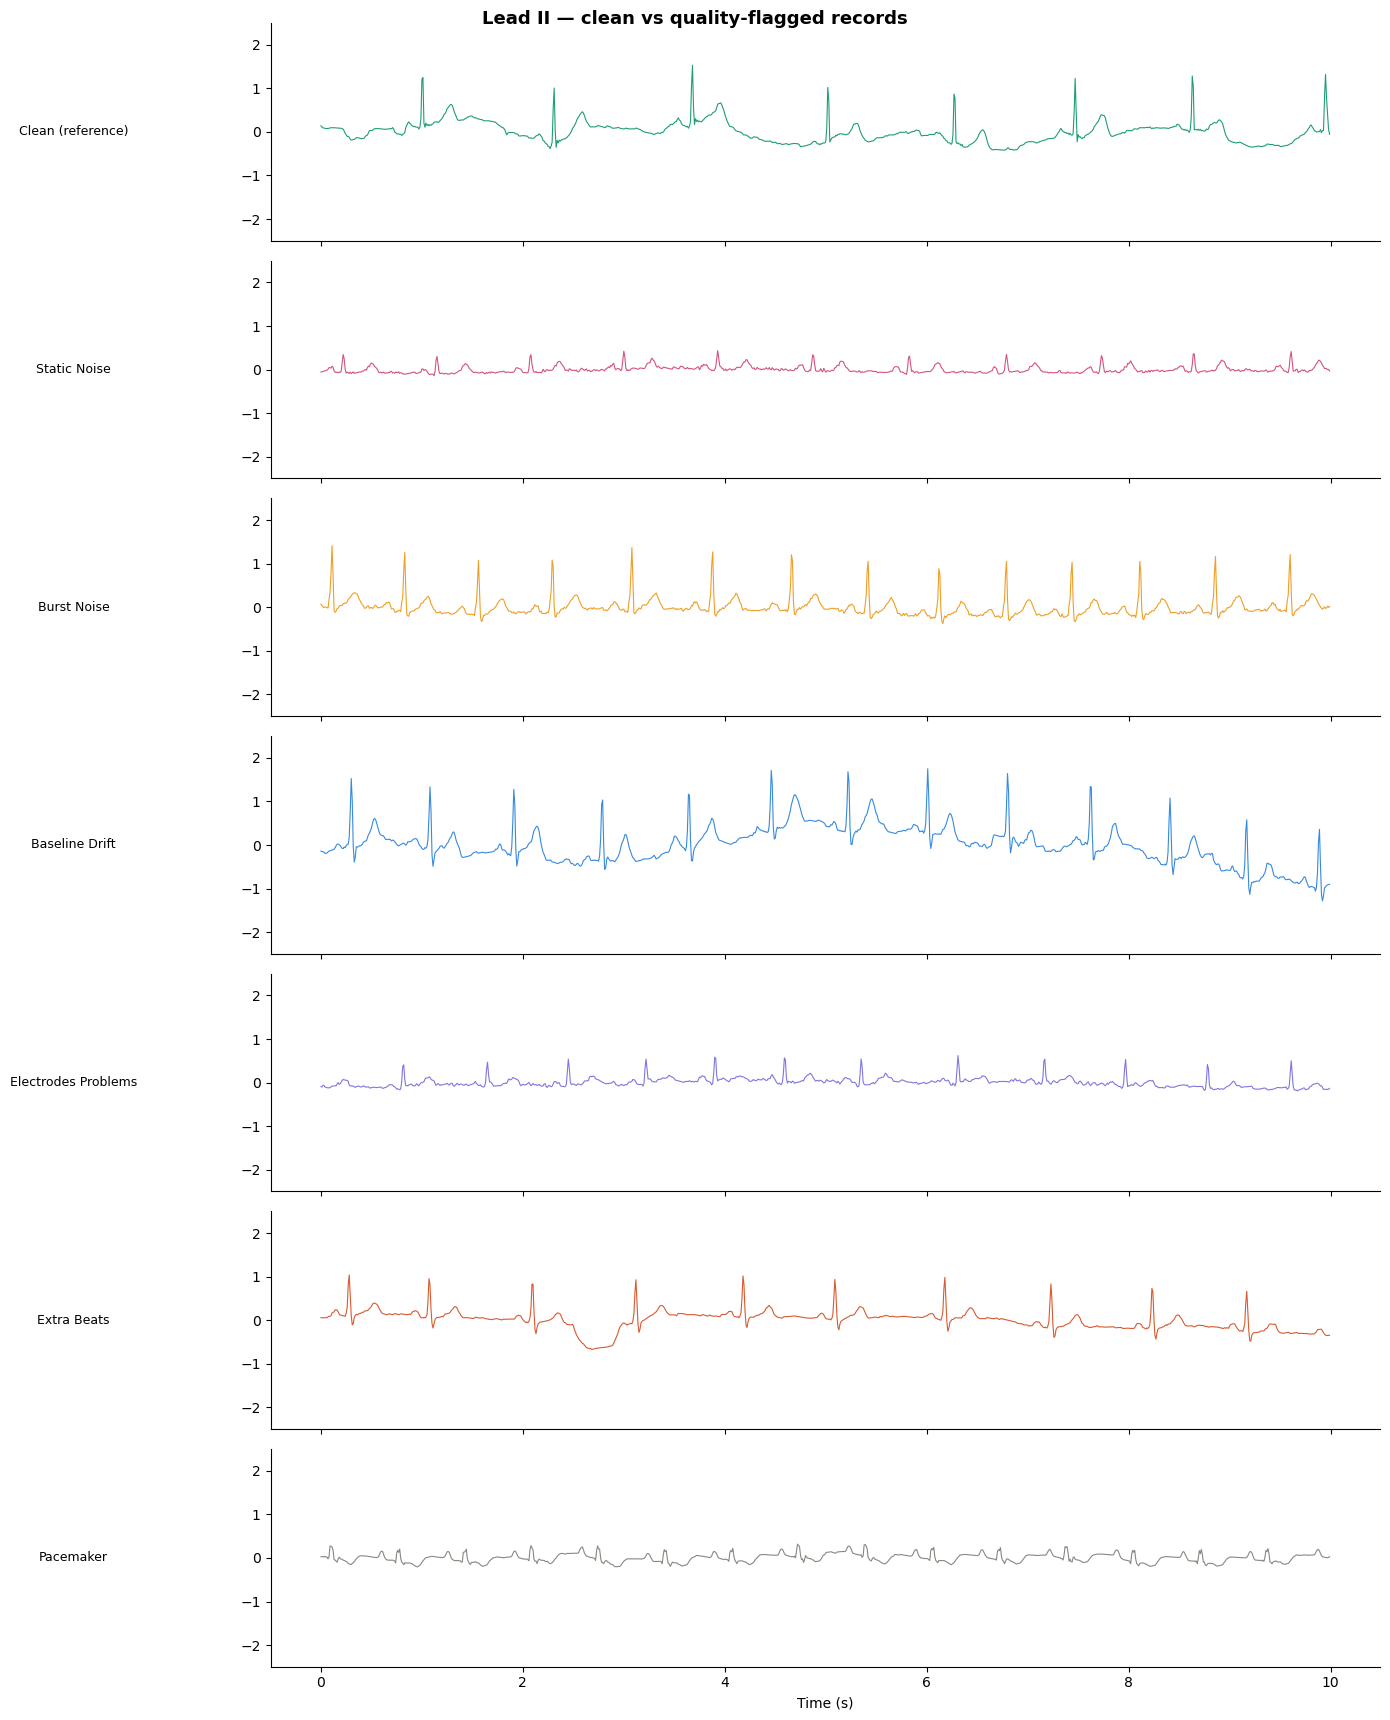

In [30]:
# Load examples of each quality type
fig = plot_quality_comparison(quality_samples, fs=100)
plt.show()

### Decision in data handling 
1. Baseline drift — this is removed by a bandpass filter (high-pass at 0.5 Hz cuts the slow drift). No special handling needed beyond standard preprocessing.
2. Static noise — partially by the low-pass filter (40 Hz cutoff). Residual noise may remain but the model should be robust to it given 3,206 flagged records are in the training set — it will see plenty of noisy examples.
3. Pacemaker and electrodes problems — only 14 and 28 records respectively. Too rare to meaningfully affect training but worth flagging in your validation report. Note their presence in the test set specifically:

In [31]:
# Check how many flagged records land in each split
quality_cols = ['static_noise', 'burst_noise', 'baseline_drift',
                'electrodes_problems', 'extra_beats', 'pacemaker']

quality_by_split = (
    df.groupby('split')[quality_cols]
    .apply(lambda g: g.notna().sum())
)

print(quality_by_split)

       static_noise  burst_noise  baseline_drift  electrodes_problems  \
split                                                                   
test            307           38             231                    2   
train          2578          496            1122                   22   
val             321           47             226                    4   

       extra_beats  pacemaker  
split                          
test           192          2  
train         1503         10  
val            187          2  


In [32]:
# Flag clean vs noisy in test set — save for validation notebook
test_df = df[df['split'] == 'test'].copy()
test_df['has_artifact'] = test_df[quality_cols].notna().any(axis=1)

print(test_df['has_artifact'].value_counts())
print(f"Clean test records:  {(~test_df['has_artifact']).sum()}")
print(f"Noisy test records:  {test_df['has_artifact'].sum()}")

has_artifact
False    1512
True      646
Name: count, dtype: int64
Clean test records:  1512
Noisy test records:  646


In [35]:
from tqdm import tqdm

def compute_lead_stats(df: pd.DataFrame, path: Path,
                                  fs: int = 100) -> pd.DataFrame:
    """
    Compute per-lead amplitude statistics across the full cohort
    without loading all signals into memory simultaneously.

    Args:
        df (pd.DataFrame): Full dataframe with filename columns.
        path (Path): Path to PTB-XL root directory.
        fs (int): Sampling frequency.

    Returns:
        pd.DataFrame: Per-lead statistics.
    """
    key      = 'filename_lr' if fs == 100 else 'filename_hr'
    n_leads  = 12

    # Accumulators — track running statistics per lead
    sums     = np.zeros(n_leads)
    sums_sq  = np.zeros(n_leads)
    mins     = np.full(n_leads,  np.inf)
    maxs     = np.full(n_leads, -np.inf)
    n_total  = 0

    # First pass — compute mean, std, min, max
    for _, row in tqdm(df.iterrows(), total=len(df), desc='Computing stats'):
        signal, _ = wfdb.rdsamp(str(path / row[key]))
        signal    = np.array(signal)  # shape: (1000, 12)

        sums    += signal.sum(axis=0)
        sums_sq += (signal ** 2).sum(axis=0)
        mins     = np.minimum(mins, signal.min(axis=0))
        maxs     = np.maximum(maxs, signal.max(axis=0))
        n_total += signal.shape[0]  # number of timesteps accumulated

    means = sums / n_total
    stds  = np.sqrt(sums_sq / n_total - means ** 2)

    # Build output table
    stats = []
    for i, lead in enumerate(LEADS):
        stats.append({
            'lead': lead,
            'mean': round(means[i], 4),
            'std':  round(stds[i],  4),
            'min':  round(mins[i],  4),
            'max':  round(maxs[i],  4),
        })

    return pd.DataFrame(stats).set_index('lead')

In [37]:
splits = {
    'global': df,
    'train':  df[df['split'] == 'train'],
    'val':    df[df['split'] == 'val'],
    'test':   df[df['split'] == 'test'],
}

stats_dict = {}
for key, df_split in splits.items():
    print(f"{'='*60}")
    print(f"Split: {key.upper()}  ({len(df_split):,} records)")
    print(f"{'='*60}")
    
    stats_dict[key] = compute_lead_stats(df_split, DATA, fs=100)
    print('\n')

Split: GLOBAL  (21,388 records)


Computing stats: 100%|██████████| 21388/21388 [00:52<00:00, 409.33it/s]




Split: TRAIN  (17,084 records)


Computing stats: 100%|██████████| 17084/17084 [00:40<00:00, 416.74it/s]




Split: VAL  (2,146 records)


Computing stats: 100%|██████████| 2146/2146 [00:05<00:00, 414.29it/s]




Split: TEST  (2,158 records)


Computing stats: 100%|██████████| 2158/2158 [00:05<00:00, 418.04it/s]

In [39]:
def plot_lead_stats(stats_dict: dict) -> plt.Figure:
    """
    Visualize per-lead amplitude statistics across splits as heatmaps.

    Args:
        stats_dict (dict): Keys are split names, values are lead_stats DataFrames.

    Returns:
        plt.Figure
    """
    metrics = ['mean', 'std', 'min', 'max']
    n_splits = len(stats_dict)

    fig, axes = plt.subplots(len(metrics), 1, figsize=(12, 14))

    for ax, metric in zip(axes, metrics):
        # Build matrix — rows = splits, columns = leads
        matrix = pd.DataFrame(
            {key: stats[metric] for key, stats in stats_dict.items()}
        ).T

        sns.heatmap(
            matrix,
            annot=True, fmt='.3f',
            cmap='RdBu_r' if metric == 'mean' else 'Blues',
            ax=ax,
            linewidths=0.5,
            linecolor='white',
            cbar_kws={'shrink': 0.8}
        )
        ax.set_title(f'Per-lead {metric} across splits',
                     fontsize=11, fontweight='bold')
        ax.set_xlabel('Lead')
        ax.set_ylabel('Split')

    fig.suptitle('Lead amplitude statistics — cohort vs splits',
                 fontsize=13, fontweight='bold')
    fig.tight_layout()
    return fig

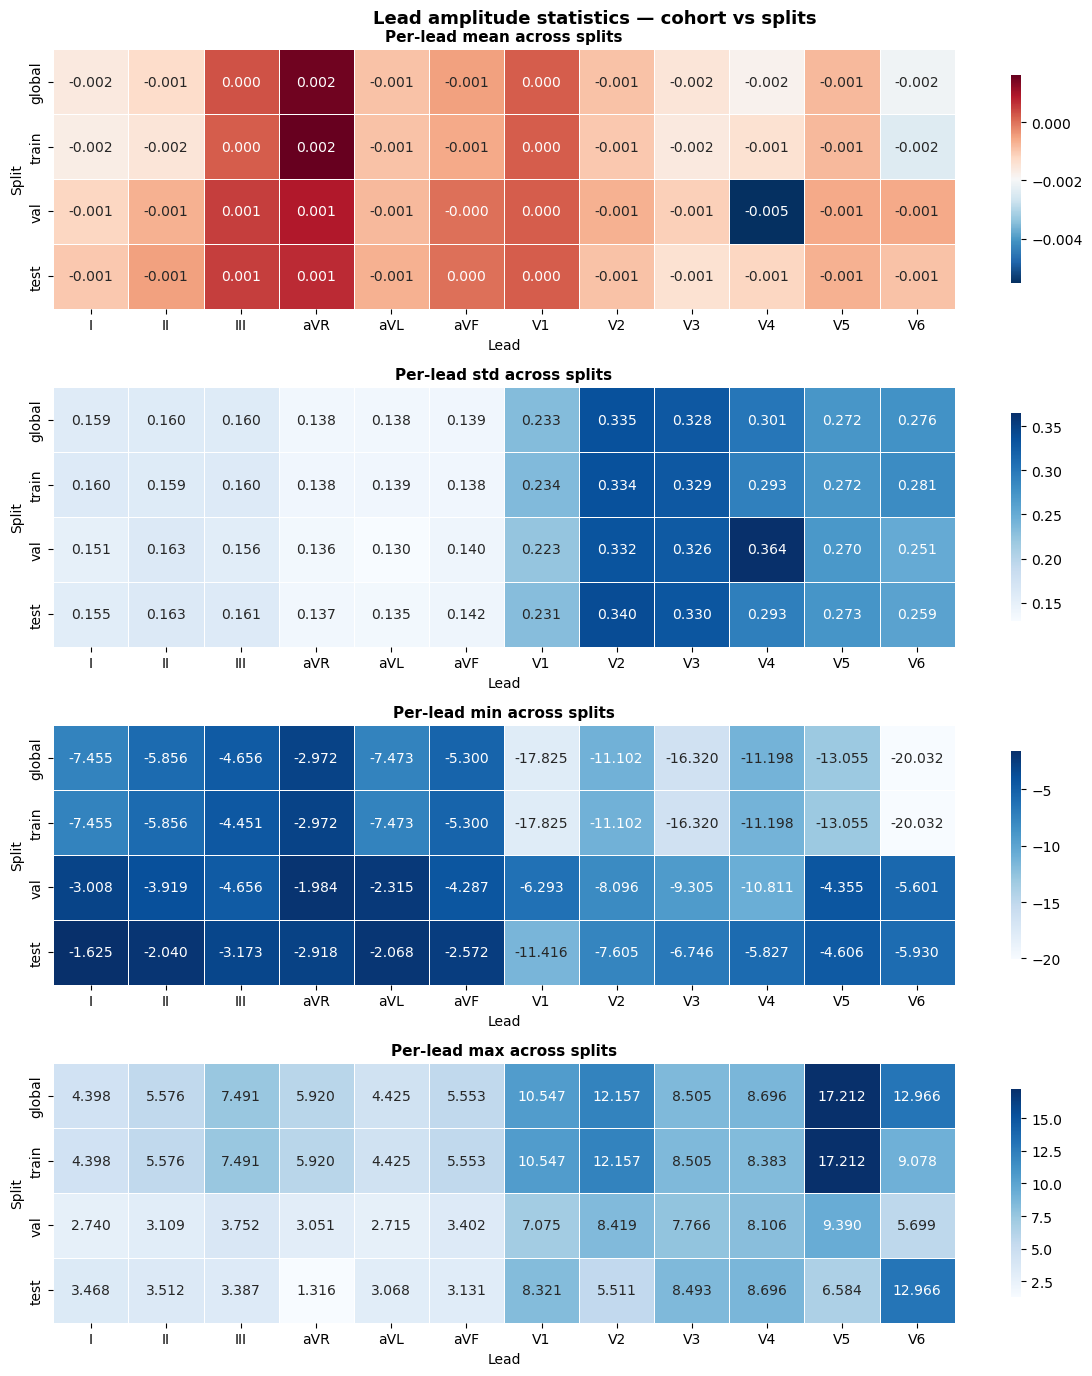

In [40]:
fig = plot_lead_stats(stats_dict)
plt.show()

## Lead Statistics Findings

1. All lead means ≈ 0 across all splits — no DC offset present.

2. Two amplitude groups identified:
   - Limb leads (I, II, III, aVR, aVL, aVF): std ≈ 0.13–0.16 mV
   - Precordial leads (V1–V6): std ≈ 0.22–0.33 mV
   This inter-lead difference is clinically meaningful and must be preserved.

3. Train/val/test statistics are consistent — stratification confirmed.

4. Extreme values present in training set (V1 min=-17.8, V6 min=-20.0).
   Likely outlier records — flagged for investigation.

Decision: Per-record z-score normalization confirmed.
Per-lead normalization explicitly rejected — would erase 
the clinically meaningful amplitude difference between 
limb and precordial leads.

## PSD

In [42]:
from scipy.signal import welch

def compute_mean_psd(df: pd.DataFrame, path: Path, fs: int = 100) -> tuple[np.ndarray, np.ndarray]:
    """
    Compute mean power spectral density per lead across a dataset
    without loading all signals into memory simultaneously.

    Args:
        df (pd.DataFrame): Dataframe with filename columns.
        path (Path): Path to PTB-XL root directory.
        fs (int): Sampling frequency in Hz.

    Returns:
        tuple:
            freqs (np.ndarray): Frequency bins in Hz.
            mean_psd (np.ndarray): Mean PSD of shape (n_freqs, 12).
    """
    key         = 'filename_lr' if fs == 100 else 'filename_hr'
    psd_accum   = None
    n_records   = 0

    for _, row in tqdm(df.iterrows(), total=len(df), desc='Computing PSD'):
        signal, _ = wfdb.rdsamp(str(path / row[key]))
        signal    = np.array(signal)  # shape: (1000, 12)

        # Compute PSD for each lead
        psds = []
        for i in range(12):
            freqs, psd = welch(signal[:, i], fs=fs, nperseg=256)
            psds.append(psd)
        psds = np.stack(psds, axis=1)  # shape: (n_freqs, 12)

        if psd_accum is None:
            psd_accum = psds
        else:
            psd_accum += psds

        n_records += 1

    mean_psd = psd_accum / n_records
    return freqs, mean_psd

In [43]:
freqs, mean_psd = compute_mean_psd(df, DATA, fs=100)
print(f"Frequency bins: {freqs.shape}")  # expect (129,) at 100 Hz
print(f"Mean PSD shape: {mean_psd.shape}")  # expect (129, 12)

Computing PSD: 100%|██████████| 21388/21388 [01:31<00:00, 234.22it/s]

Frequency bins: (129,)
Mean PSD shape: (129, 12)


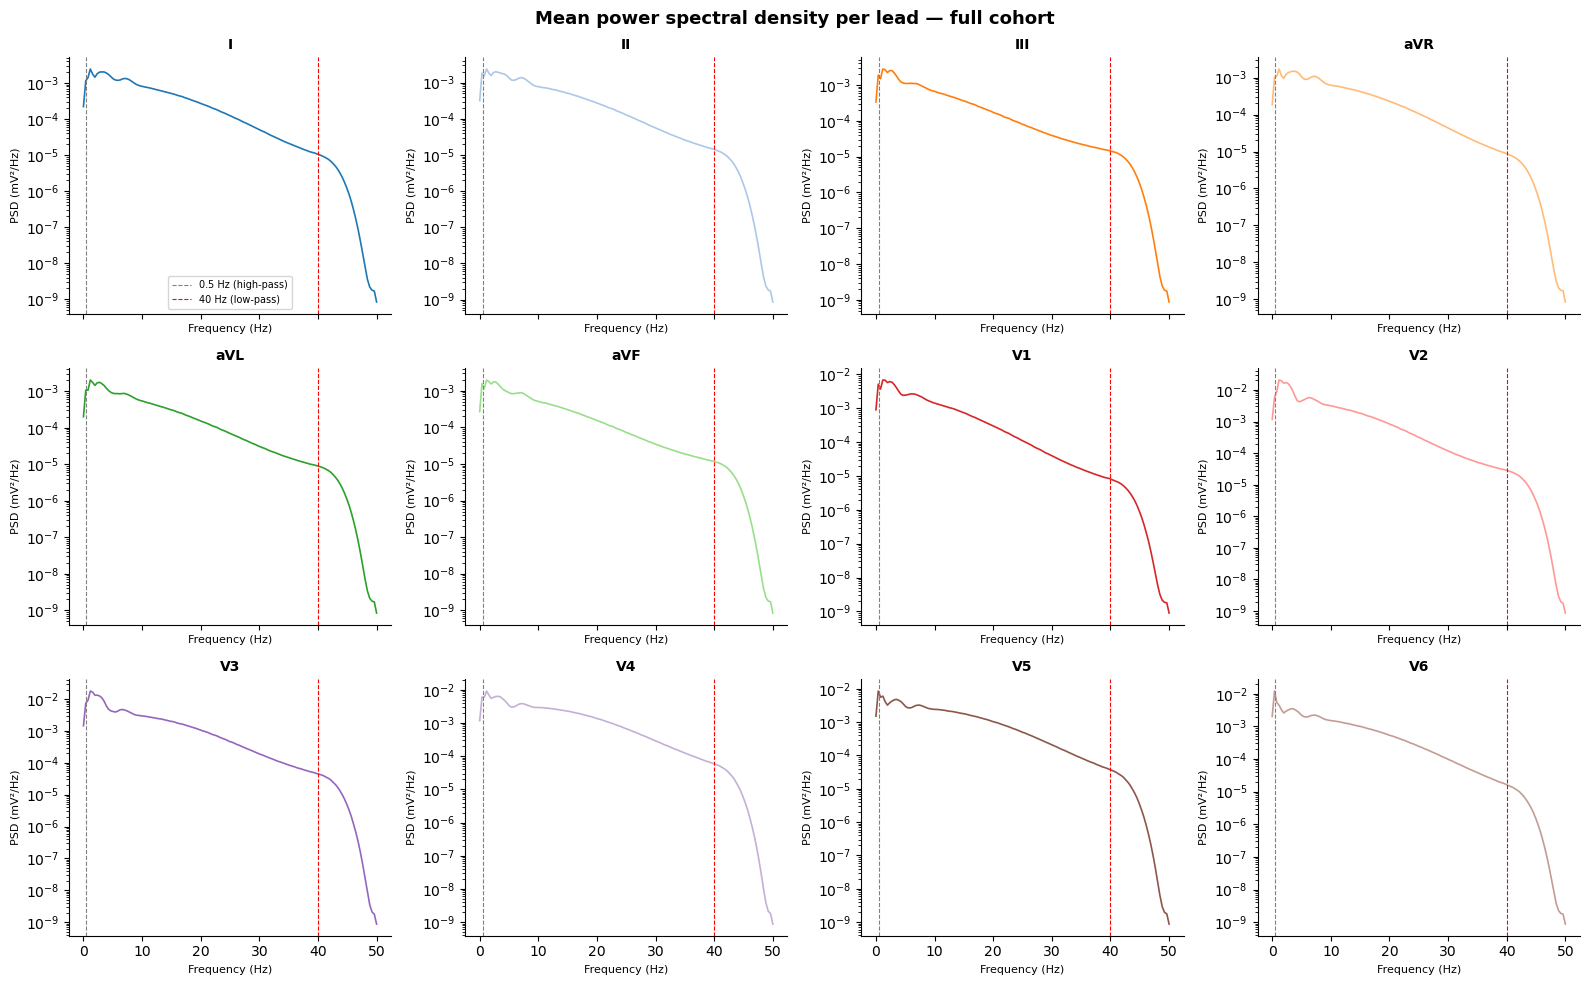

In [44]:
def plot_psd(freqs: np.ndarray, mean_psd: np.ndarray) -> plt.Figure:
    """
    Plot mean PSD per lead in a 3x4 grid.

    Args:
        freqs (np.ndarray): Frequency bins in Hz.
        mean_psd (np.ndarray): Mean PSD of shape (n_freqs, 12).

    Returns:
        plt.Figure
    """
    fig, axes = plt.subplots(3, 4, figsize=(16, 10), sharex=True, sharey=False)
    axes      = axes.flatten()
    COLORS = [plt.cm.tab20(i) for i in range(12)]
    
    for i, (ax, lead) in enumerate(zip(axes, LEADS)):
        ax.semilogy(freqs, mean_psd[:, i],
                    color=COLORS[i % len(COLORS)], linewidth=1.2)

        # Mark filter cutoffs
        ax.axvline(0.5, color='gray', linestyle='--',
                   linewidth=0.8, label='0.5 Hz (high-pass)')
        ax.axvline(40,  color='red',  linestyle='--',
                   linewidth=0.8, label='40 Hz (low-pass)')

        ax.set_title(lead, fontsize=10, fontweight='bold')
        ax.set_xlabel('Frequency (Hz)', fontsize=8)
        ax.set_ylabel('PSD (mV²/Hz)',   fontsize=8)
        sns.despine(ax=ax)

    # Single legend on first axis
    axes[0].legend(fontsize=7)

    fig.suptitle('Mean power spectral density per lead — full cohort',
                 fontsize=13, fontweight='bold')
    fig.tight_layout()
    return fig

fig = plot_psd(freqs, mean_psd)
plt.show()